# Experimento 4 — Ajuste de Splat Gaussiano sobre Defecto No Gaussiano

**Motivación:** En el Exp. 3 el defecto era exactamente gaussiano, por lo que LM obtenía coste cero. En la realidad los defectos de forja tienen forma más abrupta: bordes rígidos, fondo plano, o picos muy afilados.

**Defecto sintético:** Super-gaussiana elíptica con exponente $n=2$:

$$f(x,y) = A \exp\!\left(-\left(\frac{(x-x_0)^2}{2\sigma_x^2} + \frac{(y-y_0)^2}{2\sigma_y^2}\right)^n\right)$$

Con $n>1$ el defecto tiene:
- Centro **más plano** que una gaussiana
- Bordes **más abruptos** (caída más rápida)
- Mayor volumen real para la misma amplitud y semiejes nominales

**Preguntas a responder:**
1. ¿Converge LM aunque el modelo (gaussiana) no coincida con los datos?
2. ¿En qué dirección sesga el ajuste los parámetros (A, σ, V)?
3. ¿Qué informa el residuo sobre la forma real del defecto?
4. ¿Cómo afecta el ruido del sensor a este sesgo de modelo?

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.optimize import least_squares, minimize_scalar
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import pandas as pd

## 1. Escena sintética con defecto super-gaussiano

In [38]:
# ── Parámetros físicos (idénticos al Exp. 3) ─────────────────────────────────
R     = 52.0
FOV_X = 120.0
FOV_Y = 100.0
N_ROWS = 512
N_COLS = 614

dx = FOV_X / N_COLS
dy = FOV_Y / N_ROWS

x_vec = np.linspace(-FOV_X/2, FOV_X/2, N_COLS)
y_vec = np.linspace(-FOV_Y/2, FOV_Y/2, N_ROWS)
X_img, Y_img = np.meshgrid(x_vec, y_vec)

mask_valid = np.abs(X_img) < R
Z_nominal  = np.where(mask_valid, np.sqrt(np.maximum(R**2 - X_img**2, 0)), 0.0)

# ── Ground truth del defecto (mismos σ y A que Exp. 3b) ──────────────────────
GT_X0  = 5.0    # mm
GT_Y0  = -8.0   # mm
GT_A   = 2.5    # mm
GT_SX  = 5.0    # mm  — semieje X (σ nominal de la super-gaussiana)
GT_SY  = 10.0   # mm  — semieje Y
SG_N   = 2      # exponente de la super-gaussiana (1=gaussiana, 2=abrupta)

# ── Super-gaussiana elíptica ──────────────────────────────────────────────────
r2 = ((X_img - GT_X0)**2 / (2 * GT_SX**2)
    + (Y_img - GT_Y0)**2 / (2 * GT_SY**2))
defect = GT_A * np.exp(-(r2**SG_N))

# Volumen numérico (no tiene forma analítica cerrada para n>1)
V_gt = float(np.sum(defect) * dx * dy)

# Comparación: volumen de la gaussiana equivalente (n=1, mismos parámetros)
V_gauss_eq = GT_A * 2 * np.pi * GT_SX * GT_SY

Z_img = Z_nominal - defect

# Máscara: umbral al 5% de la amplitud
SEG_THRESHOLD = 0.05
mask_defect = defect > (SEG_THRESHOLD * GT_A)

print(f"Resolución: dx={dx:.4f} mm/px, dy={dy:.4f} mm/px")
print(f"Ground truth super-gaussiana n={SG_N}: A={GT_A}, σx={GT_SX}, σy={GT_SY}")
print(f"Volumen GT (numérico):        V = {V_gt:.4f} mm³")
print(f"Volumen gaussiana equivalente: V = {V_gauss_eq:.4f} mm³")
print(f"Factor de volumen (SG/G):      {V_gt/V_gauss_eq:.4f}")
print(f"Área de la máscara: {mask_defect.sum()} px ({mask_defect.sum()*dx*dy:.1f} mm²)")

Resolución: dx=0.1954 mm/px, dy=0.1953 mm/px
Ground truth super-gaussiana n=2: A=2.5, σx=5.0, σy=10.0
Volumen GT (numérico):        V = 693.5501 mm³
Volumen gaussiana equivalente: V = 785.3982 mm³
Factor de volumen (SG/G):      0.8831
Área de la máscara: 14191 px (541.7 mm²)


## 2. Comparación visual: Gaussiana vs Super-gaussiana

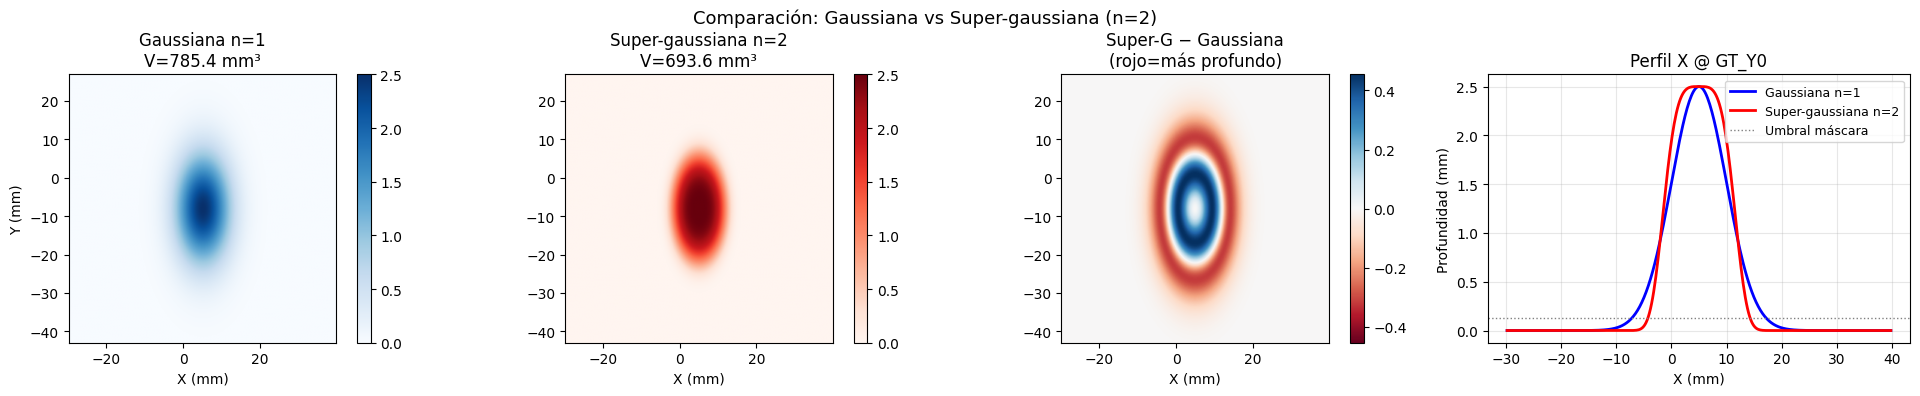

In [39]:
# Gaussiana de referencia (n=1, mismos parámetros)
defect_gauss_ref = GT_A * np.exp(-r2)

# ROI centrada en el defecto
margin_v = 3.5 * GT_SY
jx0 = max(int(np.searchsorted(x_vec, GT_X0 - margin_v)), 0)
jx1 = min(int(np.searchsorted(x_vec, GT_X0 + margin_v)), N_COLS)
jy0 = max(int(np.searchsorted(y_vec, GT_Y0 - margin_v)), 0)
jy1 = min(int(np.searchsorted(y_vec, GT_Y0 + margin_v)), N_ROWS)
ext2 = [x_vec[jx0], x_vec[jx1-1], y_vec[jy0], y_vec[jy1-1]]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

im0 = axes[0].imshow(defect_gauss_ref[jy0:jy1, jx0:jx1], origin='lower', extent=ext2,
                     cmap='Blues', vmin=0, vmax=GT_A)
axes[0].set_title(f'Gaussiana n=1\nV={V_gauss_eq:.1f} mm³')
axes[0].set_xlabel('X (mm)'); axes[0].set_ylabel('Y (mm)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(defect[jy0:jy1, jx0:jx1], origin='lower', extent=ext2,
                     cmap='Reds', vmin=0, vmax=GT_A)
axes[1].set_title(f'Super-gaussiana n={SG_N}\nV={V_gt:.1f} mm³')
axes[1].set_xlabel('X (mm)')
plt.colorbar(im1, ax=axes[1])

# Diferencia
diff_shapes = defect - defect_gauss_ref
vd = np.abs(diff_shapes[jy0:jy1, jx0:jx1]).max()
im2 = axes[2].imshow(diff_shapes[jy0:jy1, jx0:jx1], origin='lower', extent=ext2,
                     cmap='RdBu', vmin=-vd, vmax=vd)
axes[2].set_title('Super-G − Gaussiana\n(rojo=más profundo)')
axes[2].set_xlabel('X (mm)')
plt.colorbar(im2, ax=axes[2])

# Perfil X central
row_gt = int(np.argmin(np.abs(y_vec - GT_Y0)))
axes[3].plot(x_vec[jx0:jx1], defect_gauss_ref[row_gt, jx0:jx1], 'b-', lw=2, label='Gaussiana n=1')
axes[3].plot(x_vec[jx0:jx1], defect[row_gt, jx0:jx1], 'r-', lw=2, label=f'Super-gaussiana n={SG_N}')
axes[3].axhline(GT_A * SEG_THRESHOLD, color='gray', ls=':', lw=1, label='Umbral máscara')
axes[3].set_xlabel('X (mm)'); axes[3].set_ylabel('Profundidad (mm)')
axes[3].set_title('Perfil X @ GT_Y0')
axes[3].legend(fontsize=9); axes[3].grid(alpha=0.3)

plt.suptitle(f'Comparación: Gaussiana vs Super-gaussiana (n={SG_N})', fontsize=13)
plt.tight_layout()
plt.show()

## 3. SG functions + Estimación nominal sin CAD

In [40]:
def sg2d_jacobian_projection_cv2(Z, window_size=11):
    assert window_size % 2 == 1
    hw = window_size // 2
    y_idx, x_idx = np.mgrid[-hw:hw+1, -hw:hw+1]
    regressors = np.stack([
        x_idx**2, y_idx**2, x_idx * y_idx,
        x_idx, y_idx, np.ones_like(x_idx)
    ], axis=-1)
    A_mat = regressors.reshape(-1, 6)
    pseudo = np.linalg.inv(A_mat.T @ A_mat) @ A_mat.T
    kernels = pseudo.reshape(6, window_size, window_size)
    return np.stack(
        [cv2.filter2D(Z, -1, k, borderType=cv2.BORDER_REFLECT) for k in kernels],
        axis=-1
    )

def coeffs_to_physical(coeffs_px, dx, dy):
    a_ph = coeffs_px[..., 0] / dx**2
    b_ph = coeffs_px[..., 1] / dy**2
    c_ph = coeffs_px[..., 2] / (dx * dy)
    d_ph = coeffs_px[..., 3] / dx
    e_ph = coeffs_px[..., 4] / dy
    f0   = coeffs_px[..., 5]
    return np.stack([a_ph, b_ph, c_ph, d_ph, e_ph, f0], axis=-1)

# ── Sensing ring y estimación nominal sin CAD ────────────────────────────────
RING_WIDTH_MM = 15.0
ring_w_px = int(round(RING_WIDTH_MM / min(dx, dy))) | 1
kernel_ring = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ring_w_px, ring_w_px))
mask_dilated_r = cv2.dilate(mask_defect.astype(np.uint8), kernel_ring).astype(bool)
mask_ring = mask_dilated_r & ~mask_defect & mask_valid

WIN_TOPO_PX = int(round(15.0 / min(dx, dy))) | 1
coeffs_topo_px = sg2d_jacobian_projection_cv2(Z_img, window_size=WIN_TOPO_PX)
coeffs_topo_ph = coeffs_to_physical(coeffs_topo_px, dx, dy)
kappa1_ring = 2 * coeffs_topo_ph[mask_ring, 0]
med_k1 = np.median(np.abs(kappa1_ring))
med_k2 = np.median(np.abs(2 * coeffs_topo_ph[mask_ring, 1]))

THRESH_ABS, THRESH_RATIO = 5e-4, 0.15
if med_k1 > THRESH_ABS and (med_k2 / med_k1) < THRESH_RATIO:
    topology = 'cylinder'
else:
    topology = 'plane'

x_ring_pts = X_img[mask_ring]
z_ring_pts = Z_img[mask_ring]
R_init = float(np.sqrt(np.mean(z_ring_pts**2 + x_ring_pts**2)))
def _cyl_cost(R_):
    return np.sum((z_ring_pts - np.sqrt(np.maximum(R_**2 - x_ring_pts**2, 0)))**2)
res_R = minimize_scalar(_cyl_cost, bounds=(R_init*0.7, R_init*1.3), method='bounded')
R_est = float(res_R.x)
Z_nominal_est = np.where(mask_valid, np.sqrt(np.maximum(R_est**2 - X_img**2, 0)), 0.0)

print(f"Topología: {topology}  |  R_est = {R_est:.4f} mm  (GT R = {R:.4f} mm)")

Topología: cylinder  |  R_est = 51.9886 mm  (GT R = 52.0000 mm)


## 4. Ruido + mapa diferencial

σ_noise = 0.1 mm  |  SNR pico = 25.0
RMS ruido (global):   0.1001 mm
RMS ruido (máscara):  0.1004 mm


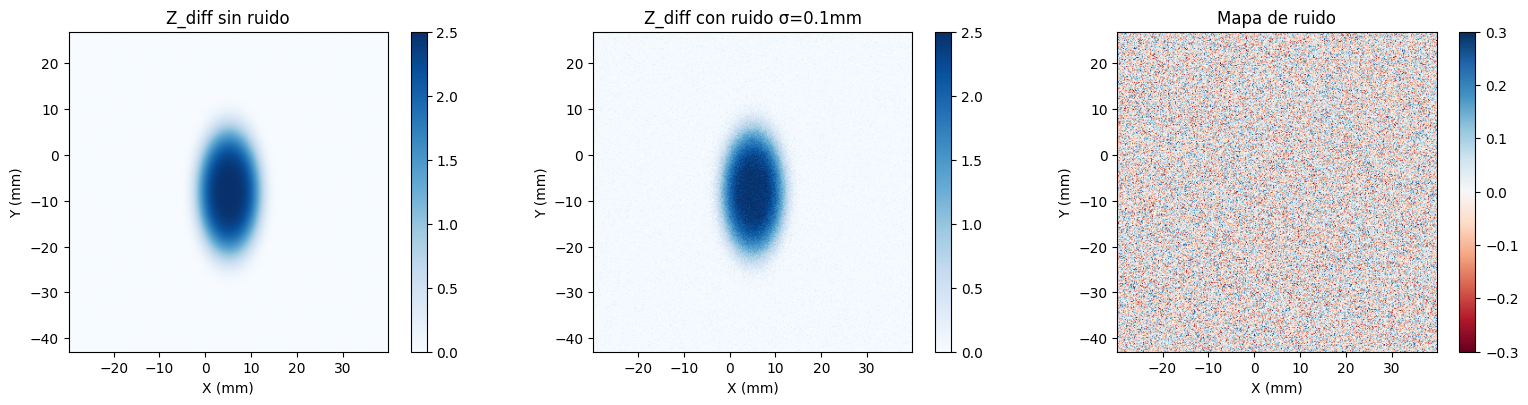

In [41]:
SIGMA_NOISE = 0.1
RNG_SEED    = 42
rng = np.random.default_rng(RNG_SEED)
noise = rng.normal(0.0, SIGMA_NOISE, size=Z_img.shape)

Z_img_n  = Z_img + noise
Z_diff   = Z_nominal_est - Z_img        # sin ruido (para referencia)
Z_diff_n = Z_nominal_est - Z_img_n      # con ruido (datos de trabajo)

print(f"σ_noise = {SIGMA_NOISE} mm  |  SNR pico = {GT_A/SIGMA_NOISE:.1f}")
print(f"RMS ruido (global):   {noise.std():.4f} mm")
print(f"RMS ruido (máscara):  {noise[mask_defect].std():.4f} mm")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (data, title) in zip(axes, [
    (Z_diff,              'Z_diff sin ruido'),
    (Z_diff_n,            f'Z_diff con ruido σ={SIGMA_NOISE}mm'),
    (noise,               'Mapa de ruido'),
]):
    if 'ruido' in title and 'con' not in title and 'Mapa' not in title:
        vm, vcm, cml = GT_A, 0, 'Blues'
    elif 'con' in title:
        vm, vcm, cml = GT_A, 0, 'Blues'
    else:
        vm, vcm, cml = 3*SIGMA_NOISE, -3*SIGMA_NOISE, 'RdBu'
    im = ax.imshow(data[jy0:jy1, jx0:jx1], origin='lower', extent=ext2,
                   cmap=cml, vmin=vcm, vmax=vm)
    ax.set_title(title); ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 5. Warm start SG + LM (modelo gaussiano)

Ajustamos una **gaussiana** $G(x,y)$ sobre datos de una **super-gaussiana**. El LM encontrará el mínimo del residuo cuadrático, que no será cero porque el modelo está mal especificado (*model mismatch*). Veremos:
- Qué parámetros elige para minimizar el error
- La estructura del residuo (revelará la forma real del defecto)

In [42]:
# ── Warm start: SG con ventana óptima ~σ_mayor ────────────────────────────────
WIN_MM = 20.0
WIN_PX = int(np.round(WIN_MM / min(dx, dy)))
WIN_PX = WIN_PX if WIN_PX % 2 == 1 else WIN_PX + 1

coeffs_px = sg2d_jacobian_projection_cv2(Z_diff_n, window_size=WIN_PX)
coeffs_ph = coeffs_to_physical(coeffs_px, dx, dy)
f0_ph = coeffs_ph[..., 5]

f0_masked = np.where(mask_defect, f0_ph, -np.inf)
peak_row, peak_col = np.unravel_index(np.argmax(f0_masked), f0_masked.shape)

a0, b0, c0_coef, d0, e0, f0_val = coeffs_ph[peak_row, peak_col, :]
H = np.array([[2*a0, c0_coef], [c0_coef, 2*b0]])
delta_phys = -np.linalg.solve(H, [d0, e0])
mu_X_ws = float(x_vec[peak_col] + delta_phys[0])
mu_Y_ws = float(y_vec[peak_row] + delta_phys[1])
A_ws    = float(f0_val)

Sigma_ws = -A_ws * np.linalg.inv(H)
evals_ws, evecs_ws = np.linalg.eigh(Sigma_ws)
ord_ = np.argsort(evals_ws)[::-1]
sx_ws = float(np.sqrt(np.abs(evals_ws[ord_[0]])))
sy_ws = float(np.sqrt(np.abs(evals_ws[ord_[1]])))
theta_ws = float(np.arctan2(evecs_ws[1, ord_[0]], evecs_ws[0, ord_[0]]))

print(f"Warm start SG ({WIN_MM}mm):")
print(f"  x0={mu_X_ws:.3f}  y0={mu_Y_ws:.3f}  A={A_ws:.3f}  "
      f"sx={sx_ws:.3f}  sy={sy_ws:.3f}  θ={np.degrees(theta_ws):.1f}°")

Warm start SG (20.0mm):
  x0=5.002  y0=-7.986  A=2.540  sx=14.007  sy=6.701  θ=90.0°


In [43]:
# ── Modelo gaussiano 2D rotado ────────────────────────────────────────────────
def gauss2d_rotated(params, x, y):
    A_p, x0_p, y0_p, sx_p, sy_p, th_p = params
    cos_t, sin_t = np.cos(th_p), np.sin(th_p)
    dx_p = x - x0_p
    dy_p = y - y0_p
    u =  dx_p * cos_t + dy_p * sin_t
    v = -dx_p * sin_t + dy_p * cos_t
    return A_p * np.exp(-0.5 * (u**2 / sx_p**2 + v**2 / sy_p**2))

# ── Ajuste LM sobre Z_diff_n (datos ruidosos de super-gaussiana) ──────────────
rows_m, cols_m = np.where(mask_defect)
x_obs = x_vec[cols_m]
y_obs = y_vec[rows_m]
z_obs = Z_diff_n[rows_m, cols_m]

def residuals_gauss(params):
    return gauss2d_rotated(params, x_obs, y_obs) - z_obs

bounds_lo = [0,      -FOV_X/2, -FOV_Y/2, 0.1,  0.1,  -np.pi]
bounds_hi = [GT_A*3,  FOV_X/2,  FOV_Y/2, 200., 200.,  np.pi]

p0 = [A_ws, mu_X_ws, mu_Y_ws, sx_ws, sy_ws, theta_ws]
p0_clipped = [float(np.clip(v, lo+1e-6, hi-1e-6))
              for v, lo, hi in zip(p0, bounds_lo, bounds_hi)]

result_lm = least_squares(
    residuals_gauss, p0_clipped,
    bounds=(bounds_lo, bounds_hi),
    method='trf', loss='linear',
    xtol=1e-10, ftol=1e-10, gtol=1e-10,
    max_nfev=10_000, verbose=0
)

A_lm, x0_lm, y0_lm, sx_lm, sy_lm, theta_lm = result_lm.x
V_lm = A_lm * 2 * np.pi * sx_lm * sy_lm
s1_lm = max(sx_lm, sy_lm)
s2_lm = min(sx_lm, sy_lm)

# Coste irreducible esperado (solo ruido): N * σ²
N_obs = len(z_obs)
cost_noise_floor = 0.5 * N_obs * SIGMA_NOISE**2
cost_model_mismatch = result_lm.cost - cost_noise_floor

print(f"Convergencia LM: {result_lm.message}")
print(f"  nfev={result_lm.nfev}")
print(f"  Coste total:          {result_lm.cost:.4e}")
print(f"  Piso de ruido (N·σ²/2): {cost_noise_floor:.4e}")
print(f"  Exceso por model mismatch: {cost_model_mismatch:.4e}")
print(f"\n═══ LM gaussiano sobre super-gaussiana ════════════════════")
print(f"  x0 = {x0_lm:.4f} mm  (GT={GT_X0}, err={x0_lm-GT_X0:+.4f})")
print(f"  y0 = {y0_lm:.4f} mm  (GT={GT_Y0}, err={y0_lm-GT_Y0:+.4f})")
print(f"  A  = {A_lm:.4f} mm  (GT={GT_A}, err={A_lm-GT_A:+.4f})")
print(f"  σ_mayor = {s1_lm:.4f} mm  (GT σ_may={GT_SY}, err={s1_lm-GT_SY:+.4f})")
print(f"  σ_menor = {s2_lm:.4f} mm  (GT σ_men={GT_SX}, err={s2_lm-GT_SX:+.4f})")
print(f"  V_lm  = {V_lm:.4f} mm³  (V_gt_num={V_gt:.4f}, err={100*(V_lm-V_gt)/V_gt:+.2f}%)")
print(f"  V_gauss_eq = {V_gauss_eq:.4f} mm³  (err vs gaussiana equiv. = {100*(V_lm-V_gauss_eq)/V_gauss_eq:+.2f}%)")

Convergencia LM: `ftol` termination condition is satisfied.
  nfev=10
  Coste total:          3.8781e+02
  Piso de ruido (N·σ²/2): 7.0955e+01
  Exceso por model mismatch: 3.1685e+02

═══ LM gaussiano sobre super-gaussiana ════════════════════
  x0 = 5.0048 mm  (GT=5.0, err=+0.0048)
  y0 = -8.0040 mm  (GT=-8.0, err=-0.0040)
  A  = 3.0468 mm  (GT=2.5, err=+0.5468)
  σ_mayor = 9.1206 mm  (GT σ_may=10.0, err=-0.8794)
  σ_menor = 4.5515 mm  (GT σ_men=5.0, err=-0.4485)
  V_lm  = 794.6946 mm³  (V_gt_num=693.5501, err=+14.58%)
  V_gauss_eq = 785.3982 mm³  (err vs gaussiana equiv. = +1.18%)


## 6. Tabla de parámetros: GT super-G vs LM gaussiano

In [44]:
rows_tbl = [
    ("X₀ (mm)",      GT_X0,   x0_lm,  GT_X0 - x0_lm),
    ("Y₀ (mm)",      GT_Y0,   y0_lm,  GT_Y0 - y0_lm),
    ("A (mm)",       GT_A,    A_lm,   GT_A  - A_lm),
    ("σ_mayor (mm)", GT_SY,   s1_lm,  GT_SY - s1_lm),
    ("σ_menor (mm)", GT_SX,   s2_lm,  GT_SX - s2_lm),
    ("V num (mm³)",  V_gt,    V_lm,   V_gt  - V_lm),
]
df = pd.DataFrame(rows_tbl, columns=["Parámetro", "GT super-G", "LM gaussiano", "Error abs"])
df["Error rel %"] = 100 * df["Error abs"].abs() / df["GT super-G"].abs()
print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nNota: V_gt numérica={V_gt:.2f} mm³  vs  V_gauss_eq analítica={V_gauss_eq:.2f} mm³  "
      f"(factor {V_gt/V_gauss_eq:.3f}x)")

   Parámetro  GT super-G  LM gaussiano  Error abs  Error rel %
     X₀ (mm)      5.0000        5.0048    -0.0048       0.0957
     Y₀ (mm)     -8.0000       -8.0040     0.0040       0.0499
      A (mm)      2.5000        3.0468    -0.5468      21.8730
σ_mayor (mm)     10.0000        9.1206     0.8794       8.7944
σ_menor (mm)      5.0000        4.5515     0.4485       8.9707
 V num (mm³)    693.5501      794.6946  -101.1445      14.5836

Nota: V_gt numérica=693.55 mm³  vs  V_gauss_eq analítica=785.40 mm³  (factor 0.883x)


## 7. Análisis del residuo — qué revela sobre la forma real

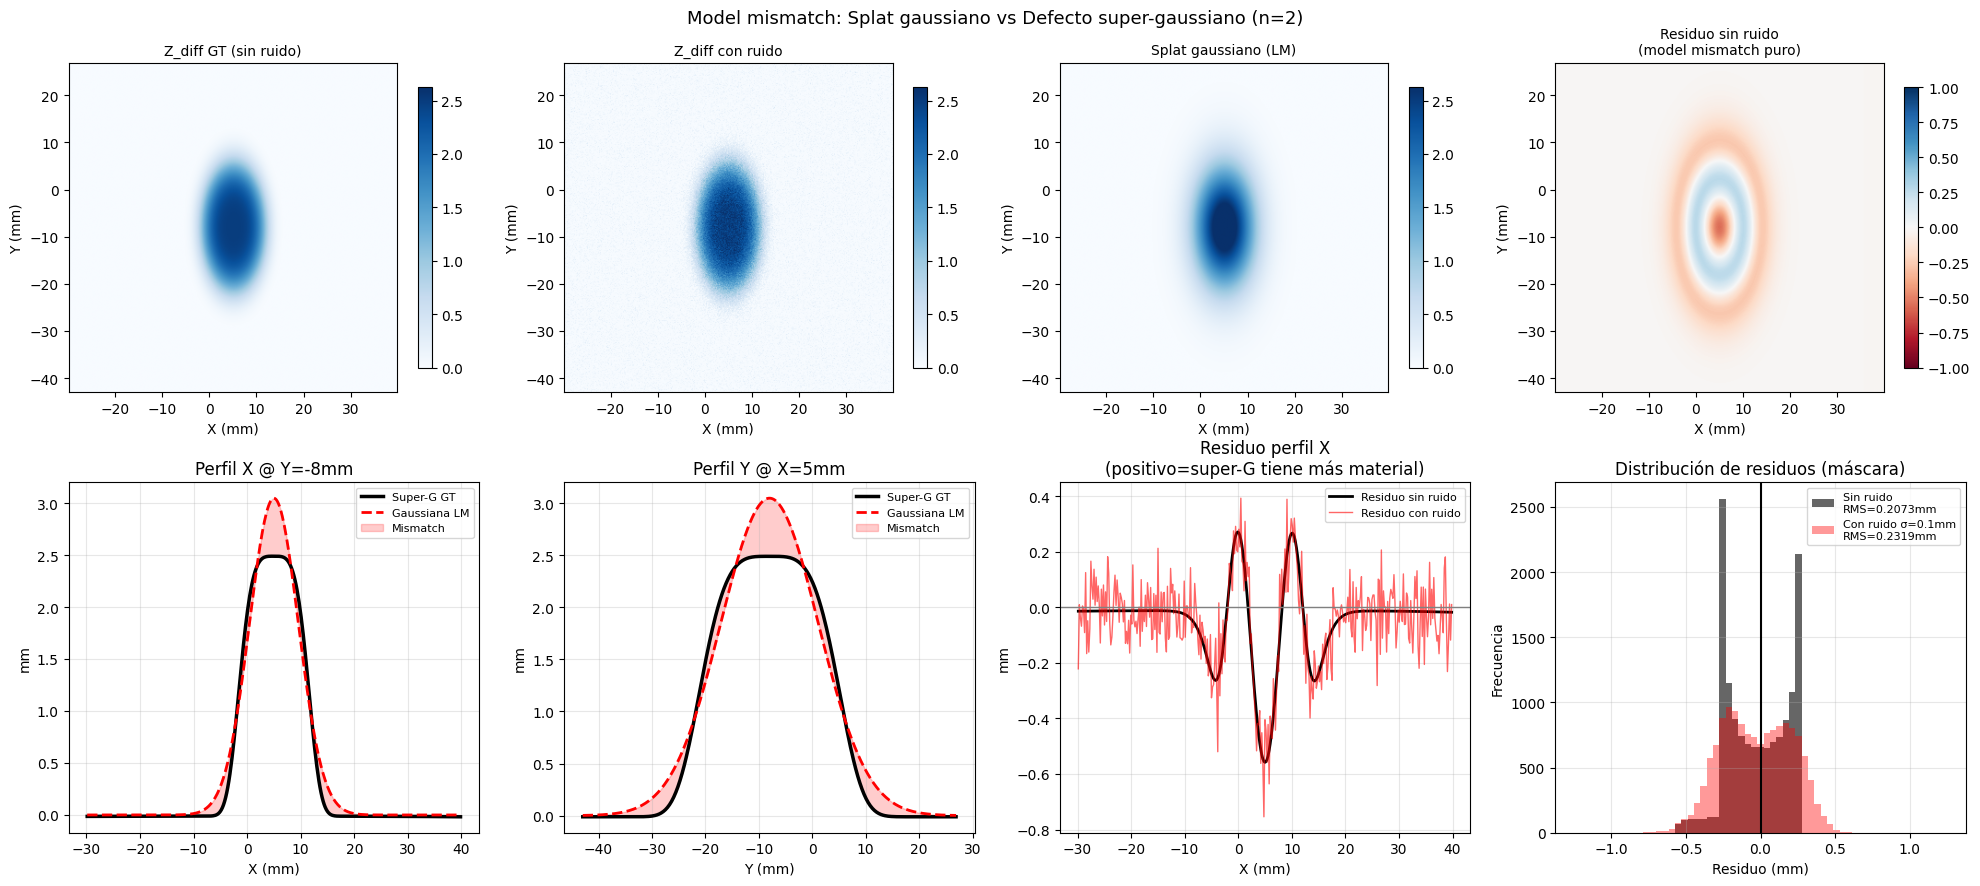

In [45]:
gauss_lm = gauss2d_rotated([A_lm, x0_lm, y0_lm, sx_lm, sy_lm, theta_lm], X_img, Y_img)
residuo_lm = Z_diff_n - gauss_lm  # datos ruidosos − modelo gaussiano ajustado
residuo_clean = Z_diff - gauss_lm  # sin ruido (para ver la estructura pura del mismatch)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

# Fila superior: mapas 2D
vmax_c = GT_A * 1.05
vmax_r = GT_A * 0.4

def show(ax, data, title, vmin=0, vmax=None, cmap='Blues'):
    vm = vmax if vmax is not None else np.abs(data[jy0:jy1, jx0:jx1]).max()
    im = ax.imshow(data[jy0:jy1, jx0:jx1], origin='lower', extent=ext2,
                   cmap=cmap, vmin=vmin, vmax=vm)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')
    plt.colorbar(im, ax=ax, shrink=0.8)

show(axes[0,0], Z_diff,       'Z_diff GT (sin ruido)',      vmax=vmax_c)
show(axes[0,1], Z_diff_n,     'Z_diff con ruido',           vmax=vmax_c)
show(axes[0,2], gauss_lm,     'Splat gaussiano (LM)',       vmax=vmax_c)
show(axes[0,3], residuo_clean,'Residuo sin ruido\n(model mismatch puro)',
     vmin=-vmax_r, vmax=vmax_r, cmap='RdBu')

# Fila inferior: perfiles 1D
row_gt = int(np.argmin(np.abs(y_vec - GT_Y0)))
col_gt = int(np.argmin(np.abs(x_vec - GT_X0)))

# Perfil X
axes[1,0].plot(x_vec[jx0:jx1], Z_diff[row_gt, jx0:jx1],   'k-',  lw=2.5, label='Super-G GT')
axes[1,0].plot(x_vec[jx0:jx1], gauss_lm[row_gt, jx0:jx1], 'r--', lw=2,   label='Gaussiana LM')
axes[1,0].fill_between(x_vec[jx0:jx1],
    Z_diff[row_gt, jx0:jx1], gauss_lm[row_gt, jx0:jx1],
    alpha=0.2, color='red', label='Mismatch')
axes[1,0].set_xlabel('X (mm)'); axes[1,0].set_ylabel('mm')
axes[1,0].set_title(f'Perfil X @ Y={GT_Y0:.0f}mm')
axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)

# Perfil Y
axes[1,1].plot(y_vec[jy0:jy1], Z_diff[jy0:jy1, col_gt],   'k-',  lw=2.5, label='Super-G GT')
axes[1,1].plot(y_vec[jy0:jy1], gauss_lm[jy0:jy1, col_gt], 'r--', lw=2,   label='Gaussiana LM')
axes[1,1].fill_between(y_vec[jy0:jy1],
    Z_diff[jy0:jy1, col_gt], gauss_lm[jy0:jy1, col_gt],
    alpha=0.2, color='red', label='Mismatch')
axes[1,1].set_xlabel('Y (mm)'); axes[1,1].set_ylabel('mm')
axes[1,1].set_title(f'Perfil Y @ X={GT_X0:.0f}mm')
axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)

# Residuo perfil X
axes[1,2].plot(x_vec[jx0:jx1], residuo_clean[row_gt, jx0:jx1], 'k-', lw=2,
               label='Residuo sin ruido')
axes[1,2].plot(x_vec[jx0:jx1], residuo_lm[row_gt, jx0:jx1], 'r-', lw=1, alpha=0.6,
               label='Residuo con ruido')
axes[1,2].axhline(0, color='gray', lw=1)
axes[1,2].set_xlabel('X (mm)'); axes[1,2].set_ylabel('mm')
axes[1,2].set_title('Residuo perfil X\n(positivo=super-G tiene más material)')
axes[1,2].legend(fontsize=8); axes[1,2].grid(alpha=0.3)

# Histograma de residuos (con vs sin ruido)
res_clean_mask = residuo_clean[mask_defect]
res_noisy_mask = residuo_lm[mask_defect]
bins = np.linspace(-GT_A*0.5, GT_A*0.5, 60)
axes[1,3].hist(res_clean_mask, bins=bins, color='black', alpha=0.6,
               label=f'Sin ruido\nRMS={res_clean_mask.std():.4f}mm')
axes[1,3].hist(res_noisy_mask, bins=bins, color='red', alpha=0.4,
               label=f'Con ruido σ={SIGMA_NOISE}mm\nRMS={res_noisy_mask.std():.4f}mm')
axes[1,3].axvline(0, color='k', lw=1.5)
axes[1,3].set_xlabel('Residuo (mm)'); axes[1,3].set_ylabel('Frecuencia')
axes[1,3].set_title('Distribución de residuos (máscara)')
axes[1,3].legend(fontsize=8); axes[1,3].grid(alpha=0.3)

plt.suptitle(f'Model mismatch: Splat gaussiano vs Defecto super-gaussiano (n={SG_N})',
             fontsize=13)
plt.tight_layout()
plt.show()

## 8. Visualización 3D: datos vs splat vs residuo

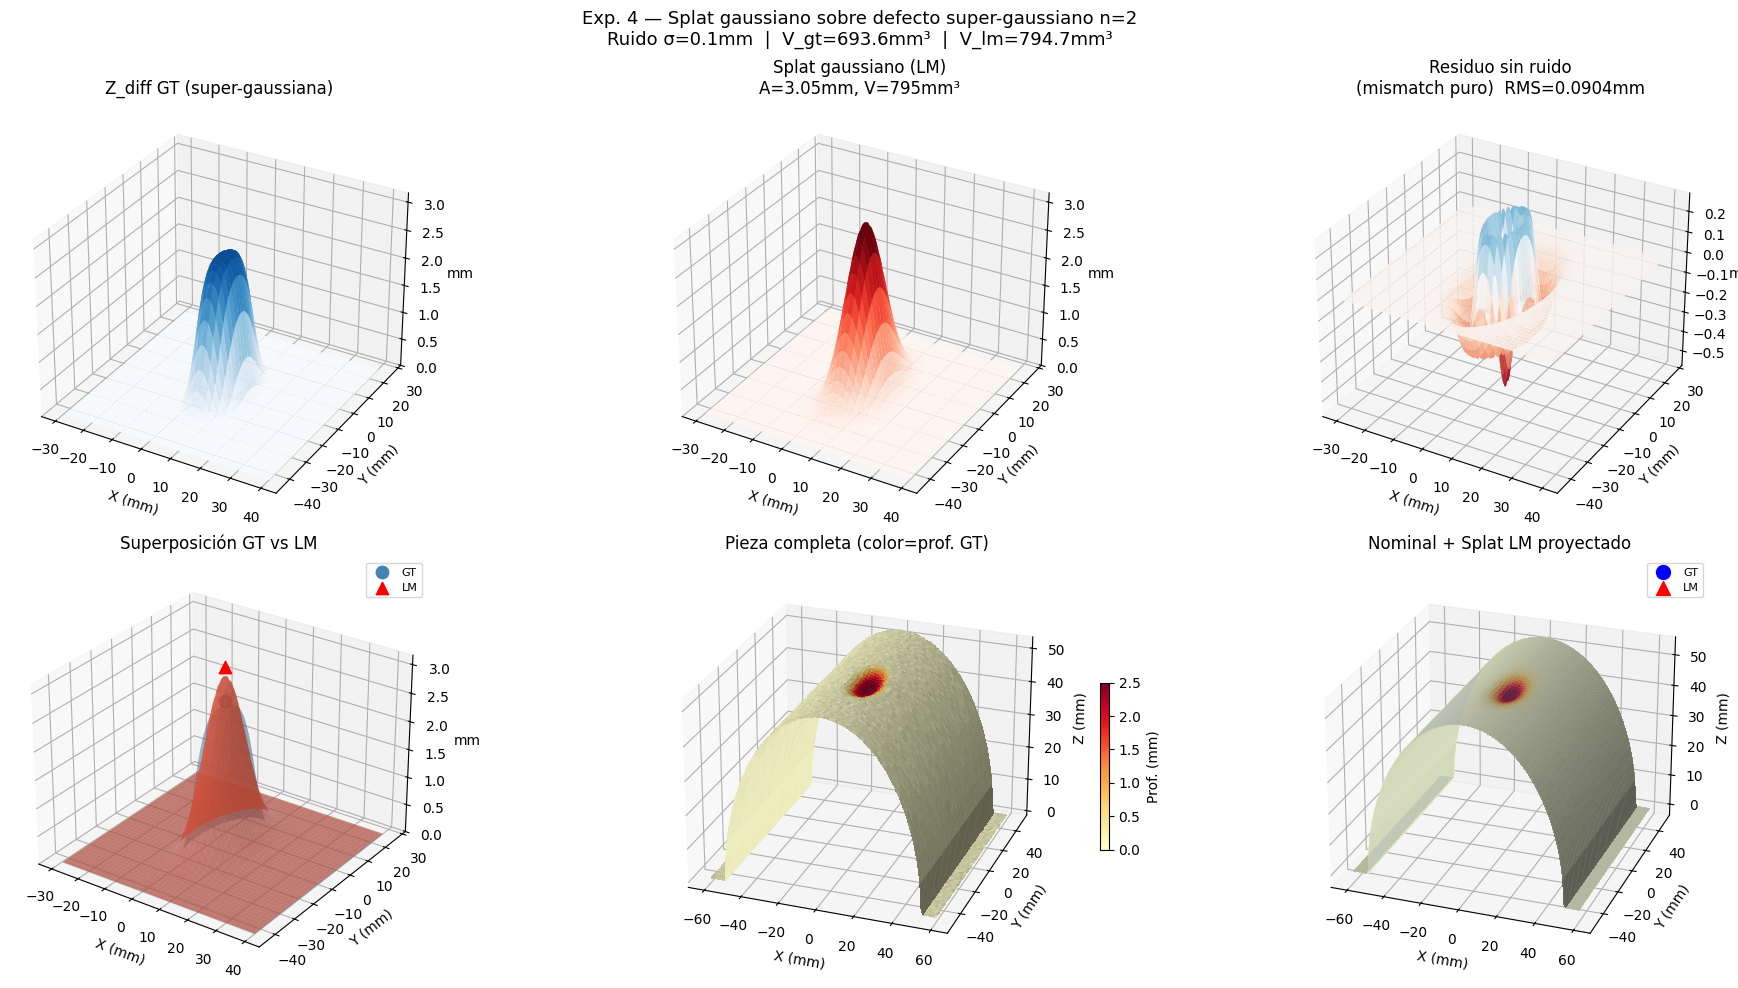

In [46]:
st = 2
Xroi  = X_img[jy0:jy1:st, jx0:jx1:st]
Yroi  = Y_img[jy0:jy1:st, jx0:jx1:st]
Zgt   = Z_diff[jy0:jy1:st, jx0:jx1:st]
Zobs  = Z_diff_n[jy0:jy1:st, jx0:jx1:st]
Zlm   = gauss_lm[jy0:jy1:st, jx0:jx1:st]
Rclean = residuo_clean[jy0:jy1:st, jx0:jx1:st]

rc = 50
vmax3 = GT_A * 1.1
vr = max(np.abs(Rclean).max(), 0.05)

fig = plt.figure(figsize=(20, 10))

ax1 = fig.add_subplot(2, 3, 1, projection='3d')
ax1.plot_surface(Xroi, Yroi, Zgt, cmap='Blues', alpha=0.95, rcount=rc, ccount=rc,
                 vmin=0, vmax=vmax3)
ax1.set_title('Z_diff GT (super-gaussiana)'); ax1.set_zlim(0, vmax3*1.15)
ax1.set_xlabel('X (mm)'); ax1.set_ylabel('Y (mm)'); ax1.set_zlabel('mm')
ax1.view_init(elev=30, azim=-60)

ax2 = fig.add_subplot(2, 3, 2, projection='3d')
ax2.plot_surface(Xroi, Yroi, Zlm, cmap='Reds', alpha=0.95, rcount=rc, ccount=rc,
                 vmin=0, vmax=vmax3)
ax2.set_title(f'Splat gaussiano (LM)\nA={A_lm:.2f}mm, V={V_lm:.0f}mm³')
ax2.set_zlim(0, vmax3*1.15)
ax2.set_xlabel('X (mm)'); ax2.set_ylabel('Y (mm)'); ax2.set_zlabel('mm')
ax2.view_init(elev=30, azim=-60)

ax3 = fig.add_subplot(2, 3, 3, projection='3d')
ax3.plot_surface(Xroi, Yroi, Rclean, cmap='RdBu', alpha=0.9, rcount=rc, ccount=rc,
                 vmin=-vr, vmax=vr)
ax3.set_title(f'Residuo sin ruido\n(mismatch puro)  RMS={np.sqrt((Rclean**2).mean()):.4f}mm')
ax3.set_xlabel('X (mm)'); ax3.set_ylabel('Y (mm)'); ax3.set_zlabel('mm')
ax3.view_init(elev=30, azim=-60)

# Superposición translúcida
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
ax4.plot_surface(Xroi, Yroi, Zgt,  color='steelblue', alpha=0.30, rcount=rc, ccount=rc)
ax4.plot_surface(Xroi, Yroi, Zlm,  color='tomato',    alpha=0.65, rcount=rc, ccount=rc)
ax4.scatter([GT_X0], [GT_Y0], [GT_A*1.05], color='steelblue', s=80, label='GT')
ax4.scatter([x0_lm], [y0_lm], [A_lm*1.05], color='red', s=80, marker='^', label='LM')
ax4.set_title('Superposición GT vs LM')
ax4.set_zlim(0, vmax3*1.15)
ax4.set_xlabel('X (mm)'); ax4.set_ylabel('Y (mm)'); ax4.set_zlabel('mm')
ax4.legend(fontsize=8); ax4.view_init(elev=28, azim=-55)

# Pieza completa
step3d = 4
Xs = X_img[::step3d, ::step3d]
Ys = Y_img[::step3d, ::step3d]
norm_d = plt.Normalize(vmin=0, vmax=GT_A)
cmap_d = plt.cm.YlOrRd

ax5 = fig.add_subplot(2, 3, 5, projection='3d')
Zn_sub = Z_nominal_est[::step3d, ::step3d]
Zi_sub = Z_img_n[::step3d, ::step3d]
face_colors = cmap_d(norm_d(defect[::step3d, ::step3d]))
ax5.plot_surface(Xs, Ys, Zi_sub, facecolors=face_colors, alpha=0.95,
                 rcount=80, ccount=80, linewidth=0, antialiased=False)
sm = plt.cm.ScalarMappable(cmap=cmap_d, norm=norm_d)
sm.set_array([])
fig.colorbar(sm, ax=ax5, shrink=0.4, label='Prof. (mm)')
ax5.set_title('Pieza completa (color=prof. GT)')
ax5.set_xlabel('X (mm)'); ax5.set_ylabel('Y (mm)'); ax5.set_zlabel('Z (mm)')
ax5.view_init(elev=25, azim=-70)

# Nominal + splat LM proyectado
ax6 = fig.add_subplot(2, 3, 6, projection='3d')
ax6.plot_surface(Xs, Ys, Zn_sub, color='lightsteelblue', alpha=0.25,
                 rcount=60, ccount=60, linewidth=0)
Zsp_lm = Z_nominal_est[::step3d, ::step3d] - gauss_lm[::step3d, ::step3d]
face_sp = cmap_d(norm_d(gauss_lm[::step3d, ::step3d]))
ax6.plot_surface(Xs, Ys, Zsp_lm, facecolors=face_sp, alpha=0.90,
                 rcount=80, ccount=80, linewidth=0, antialiased=False)
ax6.scatter([GT_X0], [GT_Y0], [float(np.sqrt(max(R**2-GT_X0**2, 0))) - GT_A*0.5],
            color='blue', s=100, zorder=10, label='GT')
ax6.scatter([x0_lm], [y0_lm],  [float(np.sqrt(max(R**2-x0_lm**2, 0))) - A_lm*0.5],
            color='red', s=100, marker='^', zorder=10, label='LM')
ax6.legend(fontsize=8); ax6.set_title('Nominal + Splat LM proyectado')
ax6.set_xlabel('X (mm)'); ax6.set_ylabel('Y (mm)'); ax6.set_zlabel('Z (mm)')
ax6.view_init(elev=25, azim=-70)

plt.suptitle(f'Exp. 4 — Splat gaussiano sobre defecto super-gaussiano n={SG_N}\n'
             f'Ruido σ={SIGMA_NOISE}mm  |  V_gt={V_gt:.1f}mm³  |  V_lm={V_lm:.1f}mm³',
             fontsize=13)
plt.tight_layout()
plt.show()

## 9. Barrido del exponente n — cómo evoluciona el sesgo

Variamos $n \in \{1, 1.5, 2, 3, 4\}$ para ver cómo el sesgo en A, σ y V crece con la
"abruptness" del defecto.

In [47]:
n_range = [1.0, 1.5, 2.0, 3.0, 4.0]
sweep = []

for n_exp in n_range:
    # Defecto con exponente n_exp
    r2_n = ((X_img - GT_X0)**2 / (2*GT_SX**2)
          + (Y_img - GT_Y0)**2 / (2*GT_SY**2))
    def_n = GT_A * np.exp(-(r2_n**n_exp))
    V_gt_n = float(np.sum(def_n) * dx * dy)

    Z_img_n2  = Z_nominal - def_n + rng.normal(0, SIGMA_NOISE, Z_img.shape)
    Z_diff_n2 = Z_nominal_est - Z_img_n2

    # Warm start rápido (pico + Hessiano)
    cpx = sg2d_jacobian_projection_cv2(Z_diff_n2, window_size=WIN_PX)
    cph = coeffs_to_physical(cpx, dx, dy)
    f0m = np.where(mask_defect, cph[..., 5], -np.inf)
    pr, pc = np.unravel_index(np.argmax(f0m), f0m.shape)
    a0n, b0n, c0n, d0n, e0n, f0n_v = cph[pr, pc, :]
    Hn = np.array([[2*a0n, c0n], [c0n, 2*b0n]])
    try:
        dlt = -np.linalg.solve(Hn, [d0n, e0n])
    except np.linalg.LinAlgError:
        continue
    A0n = float(f0n_v)
    try:
        Sig_n = -A0n * np.linalg.inv(Hn)
        ev_n, evc_n = np.linalg.eigh(Sig_n)
        ord_n = np.argsort(ev_n)[::-1]
        sx0n = float(np.sqrt(np.abs(ev_n[ord_n[0]])))
        sy0n = float(np.sqrt(np.abs(ev_n[ord_n[1]])))
        th0n = float(np.arctan2(evc_n[1, ord_n[0]], evc_n[0, ord_n[0]]))
    except Exception:
        sx0n, sy0n, th0n = GT_SY, GT_SX, 0.0

    # LM gaussiano
    z_obs_n2 = Z_diff_n2[rows_m, cols_m]
    def res_n(p): return gauss2d_rotated(p, x_obs, y_obs) - z_obs_n2
    p0n = [float(np.clip(v, lo+1e-6, hi-1e-6))
           for v, lo, hi in zip([A0n, float(x_vec[pc]+dlt[0]), float(y_vec[pr]+dlt[1]),
                                  sx0n, sy0n, th0n], bounds_lo, bounds_hi)]
    try:
        res_lm_n = least_squares(res_n, p0n, bounds=(bounds_lo, bounds_hi),
                                 method='trf', xtol=1e-9, ftol=1e-9, gtol=1e-9,
                                 max_nfev=10000)
        An, x0n, y0n, sxn, syn, thn = res_lm_n.x
        s1n, s2n = max(sxn, syn), min(sxn, syn)
        Vn = An * 2 * np.pi * sxn * syn
        costn = res_lm_n.cost
    except Exception:
        An, x0n, y0n, s1n, s2n, Vn, costn = (np.nan,)*7

    sweep.append({
        'n': n_exp, 'V_gt': V_gt_n, 'V_gauss_eq': V_gauss_eq,
        'A_lm': An, 'x0_lm': x0n, 'y0_lm': y0n,
        's1_lm': s1n, 's2_lm': s2n, 'V_lm': Vn, 'cost': costn
    })
    print(f"n={n_exp:.1f}: V_gt={V_gt_n:.1f}  V_lm={Vn:.1f}  "
          f"err_V={100*(Vn-V_gt_n)/V_gt_n:+.1f}%  "
          f"A_lm={An:.3f}  s1={s1n:.2f}  s2={s2n:.2f}")

df_sweep = pd.DataFrame(sweep)

n=1.0: V_gt=782.6  V_lm=775.6  err_V=-0.9%  A_lm=2.489  s1=9.95  s2=4.98
n=1.5: V_gt=706.5  V_lm=781.1  err_V=+10.6%  A_lm=2.839  s1=9.36  s2=4.68
n=2.0: V_gt=693.6  V_lm=793.6  err_V=+14.4%  A_lm=3.042  s1=9.12  s2=4.55
n=3.0: V_gt=698.8  V_lm=816.8  err_V=+16.9%  A_lm=3.249  s1=8.95  s2=4.47
n=4.0: V_gt=709.3  V_lm=835.3  err_V=+17.8%  A_lm=3.338  s1=8.94  s2=4.46


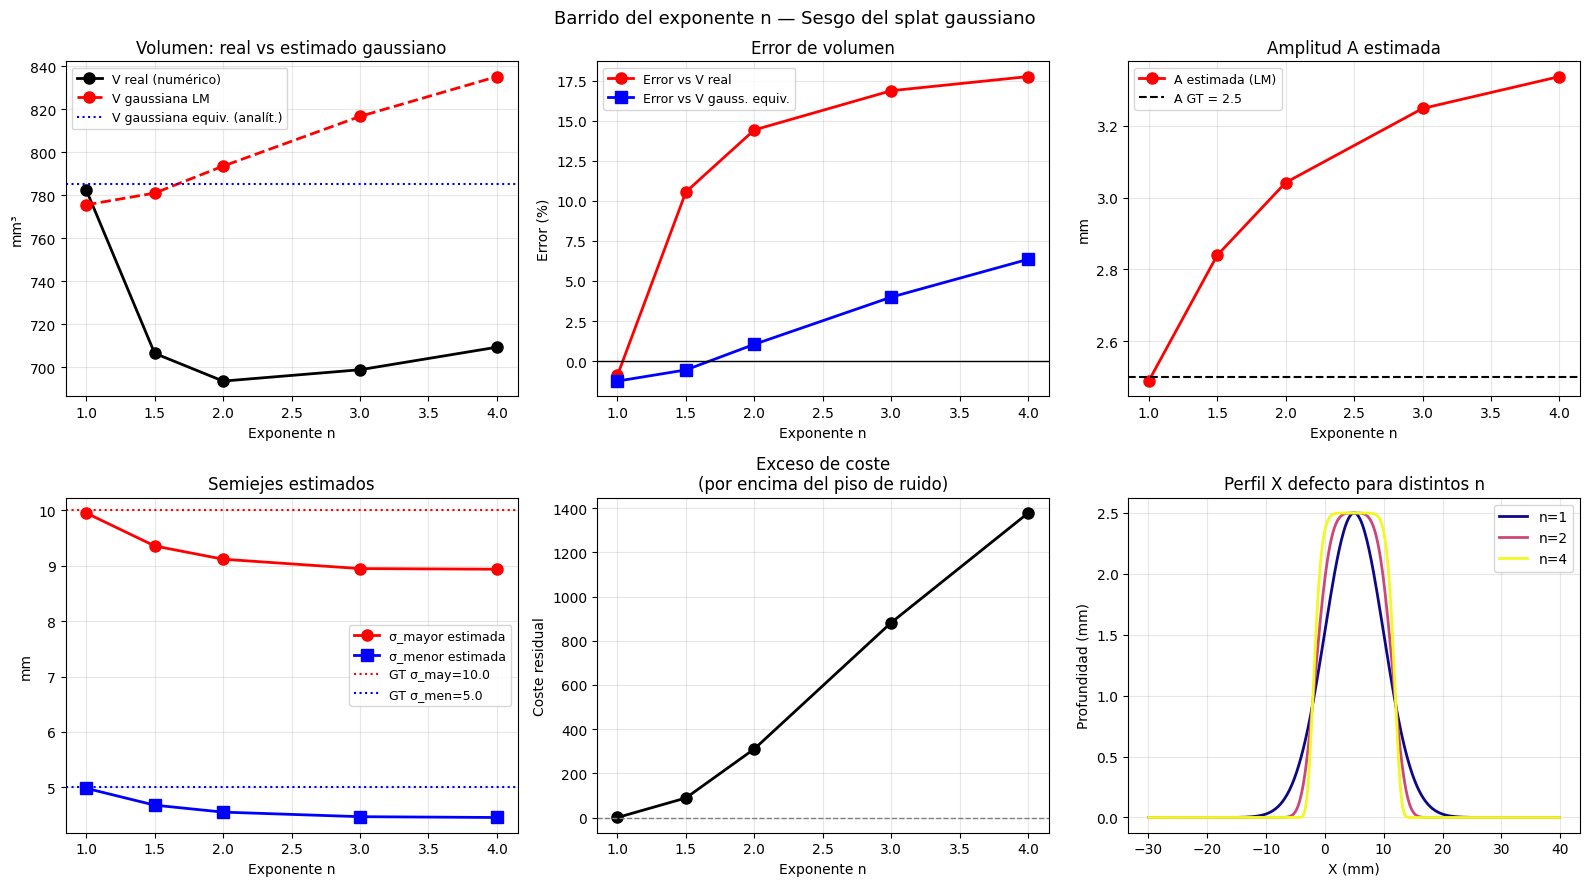

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

ax = axes[0,0]
ax.plot(df_sweep['n'], df_sweep['V_gt'],      'k-o', lw=2, ms=8, label='V real (numérico)')
ax.plot(df_sweep['n'], df_sweep['V_lm'],      'r--o', lw=2, ms=8, label='V gaussiana LM')
ax.axhline(V_gauss_eq, color='blue', ls=':', lw=1.5, label='V gaussiana equiv. (analít.)')
ax.set_xlabel('Exponente n'); ax.set_ylabel('mm³')
ax.set_title('Volumen: real vs estimado gaussiano'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[0,1]
err_V_vs_gt    = 100*(df_sweep['V_lm'] - df_sweep['V_gt'])    / df_sweep['V_gt']
err_V_vs_geq   = 100*(df_sweep['V_lm'] - df_sweep['V_gauss_eq']) / df_sweep['V_gauss_eq']
ax.plot(df_sweep['n'], err_V_vs_gt,  'r-o', lw=2, ms=8, label='Error vs V real')
ax.plot(df_sweep['n'], err_V_vs_geq, 'b-s', lw=2, ms=8, label='Error vs V gauss. equiv.')
ax.axhline(0, color='k', lw=1); ax.set_xlabel('Exponente n'); ax.set_ylabel('Error (%)')
ax.set_title('Error de volumen'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[0,2]
ax.plot(df_sweep['n'], df_sweep['A_lm'], 'r-o', lw=2, ms=8, label='A estimada (LM)')
ax.axhline(GT_A, color='k', ls='--', lw=1.5, label=f'A GT = {GT_A}')
ax.set_xlabel('Exponente n'); ax.set_ylabel('mm')
ax.set_title('Amplitud A estimada'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1,0]
ax.plot(df_sweep['n'], df_sweep['s1_lm'], 'r-o', lw=2, ms=8, label='σ_mayor estimada')
ax.plot(df_sweep['n'], df_sweep['s2_lm'], 'b-s', lw=2, ms=8, label='σ_menor estimada')
ax.axhline(GT_SY, color='red',  ls=':', lw=1.5, label=f'GT σ_may={GT_SY}')
ax.axhline(GT_SX, color='blue', ls=':', lw=1.5, label=f'GT σ_men={GT_SX}')
ax.set_xlabel('Exponente n'); ax.set_ylabel('mm')
ax.set_title('Semiejes estimados'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1,1]
excess_cost = df_sweep['cost'] - 0.5 * len(z_obs) * SIGMA_NOISE**2
ax.plot(df_sweep['n'], excess_cost, 'k-o', lw=2, ms=8)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xlabel('Exponente n'); ax.set_ylabel('Coste residual')
ax.set_title('Exceso de coste\n(por encima del piso de ruido)'); ax.grid(alpha=0.3)

# Perfiles X para n={1,2,4}
ax = axes[1,2]
cmap_n = plt.cm.plasma
for k, n_exp in enumerate([1.0, 2.0, 4.0]):
    r2_k = ((X_img[row_gt, jx0:jx1] - GT_X0)**2 / (2*GT_SX**2)
           + (Y_img[row_gt, jx0:jx1] - GT_Y0)**2 / (2*GT_SY**2))
    def_k = GT_A * np.exp(-(r2_k**n_exp))
    ax.plot(x_vec[jx0:jx1], def_k, lw=2,
            color=cmap_n(k/2), label=f'n={n_exp:.0f}')
ax.set_xlabel('X (mm)'); ax.set_ylabel('Profundidad (mm)')
ax.set_title('Perfil X defecto para distintos n'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Barrido del exponente n — Sesgo del splat gaussiano', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Multi-Splat: mezcla de K Gaussianas

La idea del **Gaussian Splatting** aplicado a defectos es representar la forma como
una **mezcla aditiva de K Gaussianas**:

$$Z_{modelo}(x,y) = \sum_{k=1}^{K} A_k \cdot \exp\!\left(-\frac{u_k^2}{2\sigma_{xk}^2} - \frac{v_k^2}{2\sigma_{yk}^2}\right)$$

El volumen sigue siendo **analítico**:

$$V = \sum_{k=1}^{K} A_k \cdot 2\pi\,\sigma_{xk}\,\sigma_{yk}$$

**Estrategia de inicialización greedy (residuo iterativo)**:
1. Ajustar G₁ con warm start SG → obtener residuo R₁ = datos − Ĝ₁
2. Localizar el pico de R₁ dentro de la máscara → inicializar G₂ ahí
3. Ajustar G₁+G₂ **conjuntamente** con LM
4. Repetir para K = 3, 5

In [49]:
import time
from scipy.optimize import least_squares as _lsq

# ── Funciones multi-splat ─────────────────────────────────────────────────────
def gauss_mixture(params, x, y, K):
    """Mezcla aditiva de K Gaussianas 2D rotadas."""
    result = np.zeros(x.size, dtype=float)
    xf, yf = x.ravel(), y.ravel()
    for k in range(K):
        A_p, x0_p, y0_p, sx_p, sy_p, th_p = params[k*6:(k+1)*6]
        cos_t = np.cos(th_p); sin_t = np.sin(th_p)
        u = (xf - x0_p)*cos_t + (yf - y0_p)*sin_t
        v = -(xf - x0_p)*sin_t + (yf - y0_p)*cos_t
        result += A_p * np.exp(-0.5*(u**2/sx_p**2 + v**2/sy_p**2))
    return result.reshape(x.shape)

def gauss_mixture_and_jac(params, x, y, K):
    """
    Residuo + Jacobiano analítico en una sola pasada (sin diferencias finitas).
    El Jacobiano para el splat k con params [A,x0,y0,sx,sy,θ]:
      g = A·exp(-½(u²/sx²+v²/sy²))
      ∂g/∂A  = g/A
      ∂g/∂x0 = g·( u·cosθ/sx²  − v·sinθ/sy²)
      ∂g/∂y0 = g·( u·sinθ/sx²  + v·cosθ/sy²)
      ∂g/∂sx = g·u²/sx³
      ∂g/∂sy = g·v²/sy³
      ∂g/∂θ  = g·u·v·(1/sy²−1/sx²)
    """
    N = len(x)
    r = np.zeros(N, dtype=float)
    J = np.zeros((N, 6*K), dtype=float)
    for k in range(K):
        A_p, x0_p, y0_p, sx_p, sy_p, th_p = params[k*6:(k+1)*6]
        cos_t = np.cos(th_p); sin_t = np.sin(th_p)
        u = (x - x0_p)*cos_t + (y - y0_p)*sin_t
        v = -(x - x0_p)*sin_t + (y - y0_p)*cos_t
        g = A_p * np.exp(-0.5*(u**2/sx_p**2 + v**2/sy_p**2))
        r += g
        b = k*6
        J[:, b+0] = g / A_p
        J[:, b+1] = g * ( u*cos_t/sx_p**2 - v*sin_t/sy_p**2)
        J[:, b+2] = g * ( u*sin_t/sx_p**2 + v*cos_t/sy_p**2)
        J[:, b+3] = g * u**2 / sx_p**3
        J[:, b+4] = g * v**2 / sy_p**3
        J[:, b+5] = g * u * v * (1/sy_p**2 - 1/sx_p**2)
    return r, J

def volume_mixture(params, K):
    p = np.asarray(params).reshape(K, 6)
    return float((p[:, 0] * 2 * np.pi * p[:, 3] * p[:, 4]).sum())

def sg_warm_start_residuo(res_field, mask, win_px, x_vec_, y_vec_, dx_, dy_,
                           fallback_sx=5.0, fallback_sy=10.0):
    res_masked = np.where(mask, res_field, -np.inf)
    pr_, pc_   = np.unravel_index(np.argmax(res_masked), res_masked.shape)
    A_init     = float(res_masked[pr_, pc_])
    x0_init    = float(x_vec_[pc_])
    y0_init    = float(y_vec_[pr_])
    cpx_ = sg2d_jacobian_projection_cv2(res_field, window_size=win_px)
    cph_ = coeffs_to_physical(cpx_, dx_, dy_)
    a_, b_, c_, d_, e_, _ = cph_[pr_, pc_, :]
    H_ = np.array([[2*a_, c_], [c_, 2*b_]])
    sigma_max = (win_px * min(dx_, dy_)) / 2.0
    try:
        delta_ = -np.linalg.solve(H_, [d_, e_])
        x0_init += float(np.clip(delta_[0], -3*dx_, 3*dx_))
        y0_init += float(np.clip(delta_[1], -3*dy_, 3*dy_))
        if A_init < 1e-4: raise ValueError("A demasiado pequeño")
        Sig_ = -A_init * np.linalg.inv(H_)
        ev_, evc_ = np.linalg.eigh(Sig_)
        ord__ = np.argsort(ev_)[::-1]
        sx_ = float(np.sqrt(np.abs(ev_[ord__[0]])))
        sy_ = float(np.sqrt(np.abs(ev_[ord__[1]])))
        th_ = float(np.arctan2(evc_[1, ord__[0]], evc_[0, ord__[0]]))
        if not (0.3 < sx_ <= sigma_max and 0.3 < sy_ <= sigma_max):
            raise ValueError(f"σ fuera de rango ({sx_:.1f}, {sy_:.1f})")
    except Exception:
        sx_, sy_, th_ = fallback_sx, fallback_sy, 0.0
    return [A_init, x0_init, y0_init, sx_, sy_, th_]

# ── Por qué es lento: diagnóstico ────────────────────────────────────────────
# Scipy-TRF hace SVD/QR del Jacobiano (m×n) en cada paso del solver.
# Coste por paso: O(m·n²).  Con m=N_obs=14191 y n=6·K, escala muy mal con K.
# La solución: submuestrear. Con N_sub puntos la SVD es (N_sub×n), ~(m/N_sub)× más rápida.
# 14191 obs / 42 params (K=7) = 338× sobreparametrizado → 1500 puntos es suficiente.
N_SUB = 1500
rng_sub = np.random.default_rng(99)
idx_sub = rng_sub.choice(len(x_obs), size=min(N_SUB, len(x_obs)), replace=False)
x_sub = x_obs[idx_sub]; y_sub = y_obs[idx_sub]; z_sub = z_obs[idx_sub]

# Benchmark: tiempo SVD interna para N_obs vs N_sub
_p5 = np.array([2.5, 5.0, -8.0, 5.0, 10.0, 0.0] * 5, dtype=float)
_, J_full = gauss_mixture_and_jac(_p5, x_obs, y_obs, 5)   # (14191, 30)
_, J_sub  = gauss_mixture_and_jac(_p5, x_sub, y_sub, 5)   # (N_sub, 30)
_nb = 50
_t0 = time.perf_counter()
for _ in range(_nb): np.linalg.svd(J_full, full_matrices=False)
t_svd_full = (time.perf_counter()-_t0)/_nb*1e3
_t0 = time.perf_counter()
for _ in range(_nb): np.linalg.svd(J_sub, full_matrices=False)
t_svd_sub = (time.perf_counter()-_t0)/_nb*1e3

print(f"Diagnóstico K=5, n_params=30:")
print(f"  N_obs={len(x_obs):5d}  →  SVD({len(x_obs):5d}×30): {t_svd_full:.1f} ms/paso")
print(f"  N_sub={len(x_sub):5d}  →  SVD({len(x_sub):5d}×30): {t_svd_sub:.1f} ms/paso")
print(f"  Speedup SVD:  {t_svd_full/t_svd_sub:.1f}×  (teórico: {len(x_obs)/len(x_sub):.1f}×)")
print(f"\nCada paso LM-TRF hace la SVD para resolver el subproblema de trust-region.")
print(f"Con nfev~200 pasos: ahorro estimado = {200*(t_svd_full-t_svd_sub)/1e3:.1f}s por K=5")

# ── Ajuste greedy multi-splat: N_sub + Jacobiano analítico ───────────────────
K_list   = [1, 2, 3, 5, 7]
K_max    = max(K_list)
results_multi = {}

p_current = list(result_lm.x)

for K in range(1, K_max + 1):
    print(f"\n── K = {K} splats ──────────────────────────────────────")

    bl = bounds_lo * K
    bh = bounds_hi * K

    if K == 1:
        p0_K = [float(np.clip(v, lo+1e-6, hi-1e-6))
                for v, lo, hi in zip(p_current, bl, bh)]
    else:
        K_prev   = K - 1
        # Residuo en los puntos sub-muestreados
        prev_fit_sub = gauss_mixture(np.array(p_current), x_sub, y_sub, K_prev)
        res_prev_sub = z_sub - prev_fit_sub.ravel()
        # Reconstruir imagen (full) para SG warm start
        res_img = np.zeros_like(Z_diff_n)
        # Interpolar residuo submuestreado a la imagen completa (solo para warm start SG)
        prev_fit_full = gauss_mixture(np.array(p_current), x_obs, y_obs, K_prev)
        res_img[rows_m, cols_m] = z_obs - prev_fit_full.ravel()
        ws_new = sg_warm_start_residuo(
            res_img, mask_defect, WIN_PX, x_vec, y_vec, dx, dy,
            fallback_sx=GT_SX * 0.7, fallback_sy=GT_SY * 0.7
        )
        print(f"  SG warm start → A={ws_new[0]:.3f}  x0={ws_new[1]:.2f}  "
              f"y0={ws_new[2]:.2f}  sx={ws_new[3]:.2f}  sy={ws_new[4]:.2f}  "
              f"θ={np.degrees(ws_new[5]):.1f}°")
        p_new = p_current + ws_new
        p0_K  = [float(np.clip(v, lo+1e-6, hi-1e-6))
                 for v, lo, hi in zip(p_new, bl, bh)]

    # Clase con caché: evita computar (r,J) dos veces cuando scipy llama
    # fun(p) y jac(p) con el mismo p
    class _CachedFit:
        def __init__(self):
            self._p = None; self._r = None; self._J = None
        def _update(self, p):
            if self._p is None or not np.array_equal(p, self._p):
                self._r, self._J = gauss_mixture_and_jac(p, x_sub, y_sub, K)
                self._p = p.copy()
        def fun(self, p):  self._update(p); return self._r - z_sub
        def jac(self, p):  self._update(p); return self._J

    _fit = _CachedFit()

    t0  = time.perf_counter()
    res = _lsq(_fit.fun, p0_K, jac=_fit.jac, bounds=(bl, bh), method='trf',
               xtol=1e-10, ftol=1e-10, gtol=1e-10, max_nfev=30_000, verbose=0)
    t_fit = time.perf_counter() - t0

    p_current = list(res.x)

    # Evaluar volumen sobre los datos completos para el reporte final
    V_K    = volume_mixture(np.array(p_current), K)
    # Coste sobre datos completos (para comparar con versión anterior)
    fit_full = gauss_mixture(np.array(p_current), x_obs, y_obs, K)
    cost_full = 0.5 * float(np.sum((fit_full.ravel() - z_obs)**2))
    excess = cost_full - cost_noise_floor

    print(f"  V = {V_K:.4f} mm³  (GT={V_gt:.4f}, err={100*(V_K-V_gt)/V_gt:+.2f}%)")
    print(f"  cost_full={cost_full:.4e}  excess={excess:.4e}  nfev={res.nfev}  t={t_fit*1e3:.1f}ms")

    if K in K_list:
        results_multi[K] = {
            'params'  : np.array(p_current).copy(),
            'V'       : V_K,
            'cost'    : cost_full,
            'excess'  : excess,
            'err_pct' : 100*(V_K - V_gt) / V_gt,
            'nfev'    : res.nfev,
            't_ms'    : t_fit * 1e3,
        }

print("\n═══ Resumen Multi-Splat (N_sub={}, Jac. analítico) ══════════════".format(N_SUB))
print(f"{'K':>4}  {'V (mm³)':>12}  {'err V%':>9}  {'excess':>12}  {'nfev':>6}  {'t (ms)':>8}")
for K in K_list:
    r = results_multi[K]
    print(f"{K:>4}  {r['V']:>12.4f}  {r['err_pct']:>+9.3f}%  "
          f"{r['excess']:>12.4e}  {r['nfev']:>6}  {r['t_ms']:>8.1f}")

Diagnóstico K=5, n_params=30:
  N_obs=14191  →  SVD(14191×30): 13.5 ms/paso
  N_sub= 1500  →  SVD( 1500×30): 1.2 ms/paso
  Speedup SVD:  11.0×  (teórico: 9.5×)

Cada paso LM-TRF hace la SVD para resolver el subproblema de trust-region.
Con nfev~200 pasos: ahorro estimado = 2.5s por K=5

── K = 1 splats ──────────────────────────────────────
  V = 797.6982 mm³  (GT=693.5501, err=+15.02%)
  cost_full=3.8884e+02  excess=3.1789e+02  nfev=7  t=3.2ms

── K = 2 splats ──────────────────────────────────────
  SG warm start → A=0.621  x0=10.08  y0=-6.87  sx=3.50  sy=7.00  θ=0.0°
  V = 762.3230 mm³  (GT=693.5501, err=+9.92%)
  cost_full=2.9485e+02  excess=2.2390e+02  nfev=187  t=74.1ms

── K = 3 splats ──────────────────────────────────────
  SG warm start → A=0.644  x0=0.49  y0=-2.06  sx=3.50  sy=7.00  θ=0.0°
  V = 716.1076 mm³  (GT=693.5501, err=+3.25%)
  cost_full=1.1049e+02  excess=3.9539e+01  nfev=95  t=63.4ms

── K = 4 splats ──────────────────────────────────────
  SG warm start → A=0.436

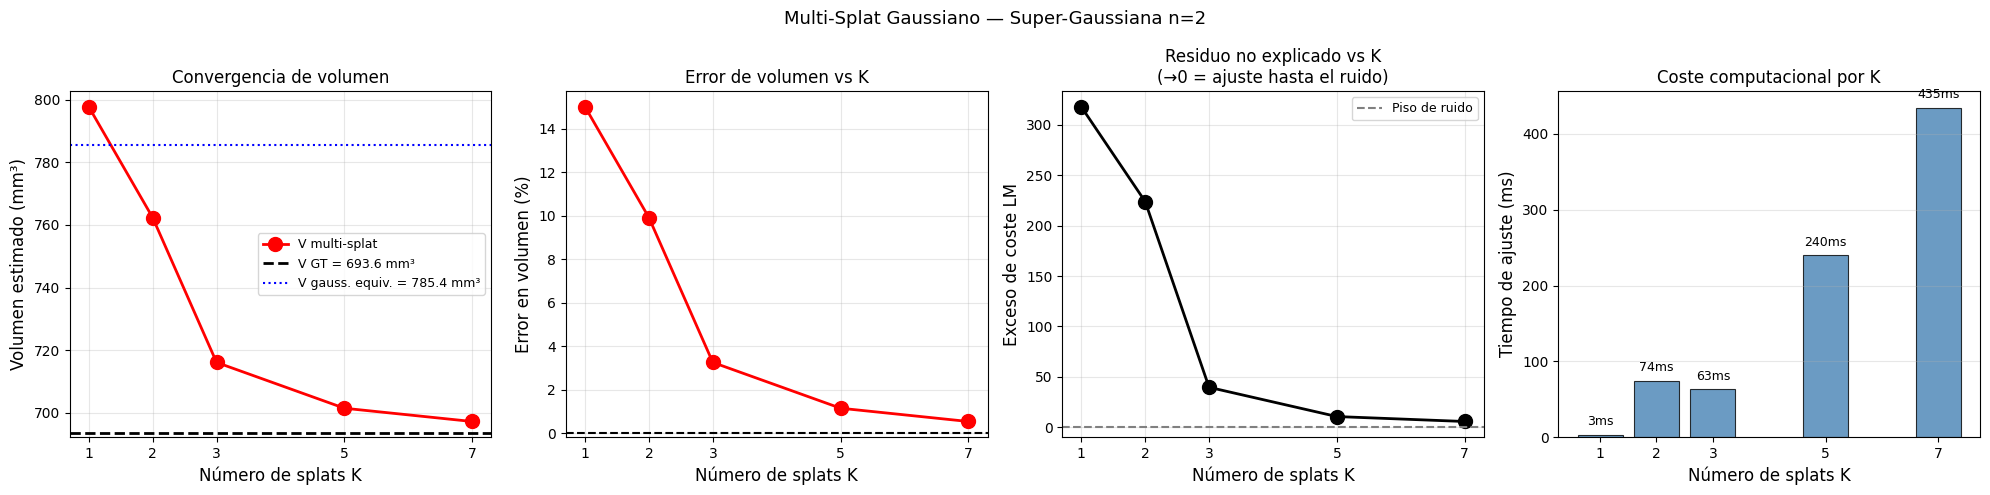

In [50]:
# ── Convergencia de volumen con K ────────────────────────────────────────────
V_vals      = [results_multi[K]['V']       for K in K_list]
excess_vals = [results_multi[K]['excess']  for K in K_list]
err_vals    = [results_multi[K]['err_pct'] for K in K_list]
t_vals      = [results_multi[K]['t_ms']    for K in K_list]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Panel 1: V(K)
axes[0].plot(K_list, V_vals, 'r-o', lw=2, ms=10, label='V multi-splat')
axes[0].axhline(V_gt,       color='k',    ls='--', lw=2,   label=f'V GT = {V_gt:.1f} mm³')
axes[0].axhline(V_gauss_eq, color='blue', ls=':',  lw=1.5, label=f'V gauss. equiv. = {V_gauss_eq:.1f} mm³')
axes[0].set_xlabel('Número de splats K', fontsize=12)
axes[0].set_ylabel('Volumen estimado (mm³)', fontsize=12)
axes[0].set_title('Convergencia de volumen', fontsize=12)
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[0].set_xticks(K_list)

# Panel 2: Error %
axes[1].plot(K_list, err_vals, 'r-o', lw=2, ms=10)
axes[1].axhline(0, color='k', ls='--', lw=1.5)
axes[1].set_xlabel('Número de splats K', fontsize=12)
axes[1].set_ylabel('Error en volumen (%)', fontsize=12)
axes[1].set_title('Error de volumen vs K', fontsize=12)
axes[1].grid(alpha=0.3); axes[1].set_xticks(K_list)

# Panel 3: Exceso de coste
axes[2].plot(K_list, excess_vals, 'k-o', lw=2, ms=10)
axes[2].axhline(0, color='gray', ls='--', lw=1.5, label='Piso de ruido')
axes[2].set_xlabel('Número de splats K', fontsize=12)
axes[2].set_ylabel('Exceso de coste LM', fontsize=12)
axes[2].set_title('Residuo no explicado vs K\n(→0 = ajuste hasta el ruido)', fontsize=12)
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3); axes[2].set_xticks(K_list)

# Panel 4: Tiempo de ajuste LM
axes[3].bar(K_list, t_vals, color='steelblue', alpha=0.8, edgecolor='k', linewidth=0.8)
for i, (K, t) in enumerate(zip(K_list, t_vals)):
    axes[3].text(K, t + max(t_vals)*0.02, f'{t:.0f}ms', ha='center', va='bottom', fontsize=9)
axes[3].set_xlabel('Número de splats K', fontsize=12)
axes[3].set_ylabel('Tiempo de ajuste (ms)', fontsize=12)
axes[3].set_title('Coste computacional por K', fontsize=12)
axes[3].grid(alpha=0.3, axis='y'); axes[3].set_xticks(K_list)

plt.suptitle(f'Multi-Splat Gaussiano — Super-Gaussiana n={SG_N}', fontsize=13)
plt.tight_layout(); plt.show()

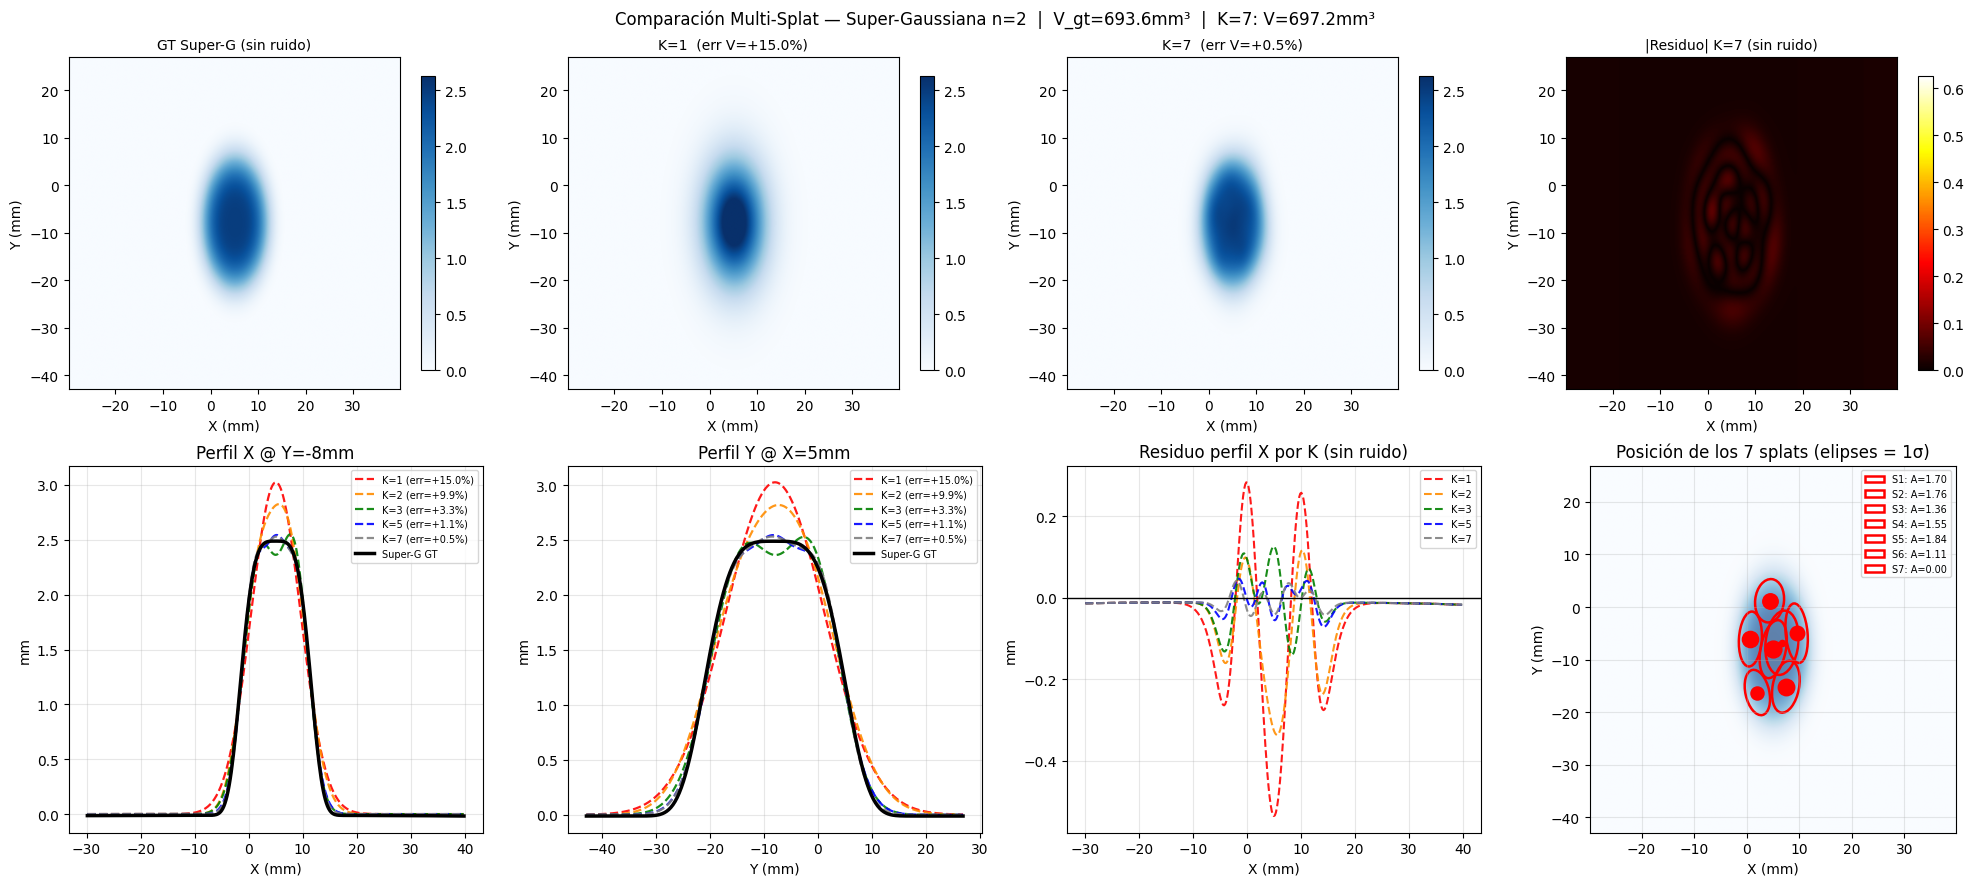

In [51]:
# ── Comparación espacial K=1 vs K_best ──────────────────────────────────────
K_best       = max(K_list)
params_best  = results_multi[K_best]['params']

fit_k1   = gauss_mixture(results_multi[1]['params'], X_img, Y_img, 1)
fit_best = gauss_mixture(params_best, X_img, Y_img, K_best)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

colors_K = {1: 'red', 2: 'darkorange', 3: 'green', 5: 'blue'}

def show2(ax, data, title, vmin=0, vmax=None, cmap='Blues'):
    vm = vmax or np.abs(data[jy0:jy1, jx0:jx1]).max()
    im = ax.imshow(data[jy0:jy1, jx0:jx1], origin='lower', extent=ext2,
                   cmap=cmap, vmin=vmin, vmax=vm)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')
    plt.colorbar(im, ax=ax, shrink=0.8)

# Fila 1: mapas 2D
show2(axes[0,0], Z_diff,
      'GT Super-G (sin ruido)', vmax=GT_A*1.05)
show2(axes[0,1], fit_k1,
      f'K=1  (err V={results_multi[1]["err_pct"]:+.1f}%)', vmax=GT_A*1.05)
show2(axes[0,2], fit_best,
      f'K={K_best}  (err V={results_multi[K_best]["err_pct"]:+.1f}%)', vmax=GT_A*1.05)
show2(axes[0,3], np.abs(Z_diff - fit_best),
      f'|Residuo| K={K_best} (sin ruido)', vmax=GT_A*0.25, cmap='hot')

# Fila 2: perfiles 1D
row_gt = int(np.argmin(np.abs(y_vec - GT_Y0)))
col_gt = int(np.argmin(np.abs(x_vec - GT_X0)))

for K in K_list:
    fit_K = gauss_mixture(results_multi[K]['params'], X_img, Y_img, K)
    lbl = f'K={K} (err={results_multi[K]["err_pct"]:+.1f}%)'
    axes[1,0].plot(x_vec[jx0:jx1], fit_K[row_gt, jx0:jx1], '--', lw=1.6,
                   color=colors_K.get(K,'gray'), label=lbl, alpha=0.9)
    axes[1,1].plot(y_vec[jy0:jy1], fit_K[jy0:jy1, col_gt], '--', lw=1.6,
                   color=colors_K.get(K,'gray'), label=lbl, alpha=0.9)
    res_X = Z_diff[row_gt, jx0:jx1] - fit_K[row_gt, jx0:jx1]
    axes[1,2].plot(x_vec[jx0:jx1], res_X, '--', lw=1.5,
                   color=colors_K.get(K,'gray'), label=f'K={K}', alpha=0.9)

axes[1,0].plot(x_vec[jx0:jx1], Z_diff[row_gt, jx0:jx1], 'k-', lw=2.5, label='Super-G GT')
axes[1,0].set_xlabel('X (mm)'); axes[1,0].set_ylabel('mm')
axes[1,0].set_title(f'Perfil X @ Y={GT_Y0:.0f}mm')
axes[1,0].legend(fontsize=7); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(y_vec[jy0:jy1], Z_diff[jy0:jy1, col_gt], 'k-', lw=2.5, label='Super-G GT')
axes[1,1].set_xlabel('Y (mm)'); axes[1,1].set_ylabel('mm')
axes[1,1].set_title(f'Perfil Y @ X={GT_X0:.0f}mm')
axes[1,1].legend(fontsize=7); axes[1,1].grid(alpha=0.3)

axes[1,2].axhline(0, color='k', lw=1)
axes[1,2].set_xlabel('X (mm)'); axes[1,2].set_ylabel('mm')
axes[1,2].set_title('Residuo perfil X por K (sin ruido)')
axes[1,2].legend(fontsize=7); axes[1,2].grid(alpha=0.3)

# Panel: posición y forma de los K_best splats
axes[1,3].imshow(Z_diff[jy0:jy1, jx0:jx1], origin='lower', extent=ext2,
                 cmap='Blues', vmax=GT_A*1.05, alpha=0.65)
for k in range(K_best):
    A_sp  = params_best[k*6]
    x0_sp = params_best[k*6+1]
    y0_sp = params_best[k*6+2]
    sx_sp = params_best[k*6+3]
    sy_sp = params_best[k*6+4]
    th_sp = params_best[k*6+5]
    axes[1,3].scatter(x0_sp, y0_sp, s=max(A_sp*80, 20), c='red', zorder=5)
    ell = plt.matplotlib.patches.Ellipse(
        (x0_sp, y0_sp), 2*sx_sp, 2*sy_sp,
        angle=np.degrees(th_sp),
        fill=False, edgecolor='red', lw=1.8, label=f'S{k+1}: A={A_sp:.2f}'
    )
    axes[1,3].add_patch(ell)
axes[1,3].set_xlim(ext2[0], ext2[1]); axes[1,3].set_ylim(ext2[2], ext2[3])
axes[1,3].set_xlabel('X (mm)'); axes[1,3].set_ylabel('Y (mm)')
axes[1,3].set_title(f'Posición de los {K_best} splats (elipses = 1σ)')
axes[1,3].legend(fontsize=7); axes[1,3].grid(alpha=0.3)

plt.suptitle(f'Comparación Multi-Splat — Super-Gaussiana n={SG_N}  '
             f'|  V_gt={V_gt:.1f}mm³  |  K={K_best}: V={results_multi[K_best]["V"]:.1f}mm³',
             fontsize=12)
plt.tight_layout(); plt.show()

## 11. Comparativa de estrategias de inicialización: SG en todos vs SG solo K=1 vs sin SG

── SG en cada K ──────────────────────────────────────────────
  K=1: err=+15.01%, nfev=  7, t=56.5 ms
  K=2: err=+9.90%, nfev= 51, t=73.9 ms
  K=3: err=+3.26%, nfev= 44, t=80.3 ms
  K=5: err=+2.18%, nfev= 79, t=127.3 ms
  K=7: err=+1.15%, nfev=121, t=193.0 ms

── SG solo en K=1, naive en K≥2 ────────────────────────────
  K=1: err=+15.01%, nfev=  7, t=62.4 ms
  K=2: err=+9.93%, nfev= 83, t=36.3 ms
  K=3: err=+3.25%, nfev= 41, t=32.7 ms
  K=5: err=+2.18%, nfev= 74, t=73.5 ms
  K=7: err=+1.15%, nfev=120, t=147.2 ms

── Sin SG (naive) ────────────────────────────────────────────
  K=1: err=+15.01%, nfev=  7, t=2.6 ms
  K=2: err=+9.93%, nfev= 83, t=44.1 ms
  K=3: err=+3.25%, nfev= 41, t=31.0 ms
  K=5: err=+2.18%, nfev= 74, t=71.4 ms
  K=7: err=+1.15%, nfev=120, t=139.8 ms

 K           SG en todos           SG solo K=1                Sin SG
------------------------------------------------------------------------
 1   +15.01%   7nfev     57ms   +15.01%   7nfev     62ms   +15.01%   7nfev   

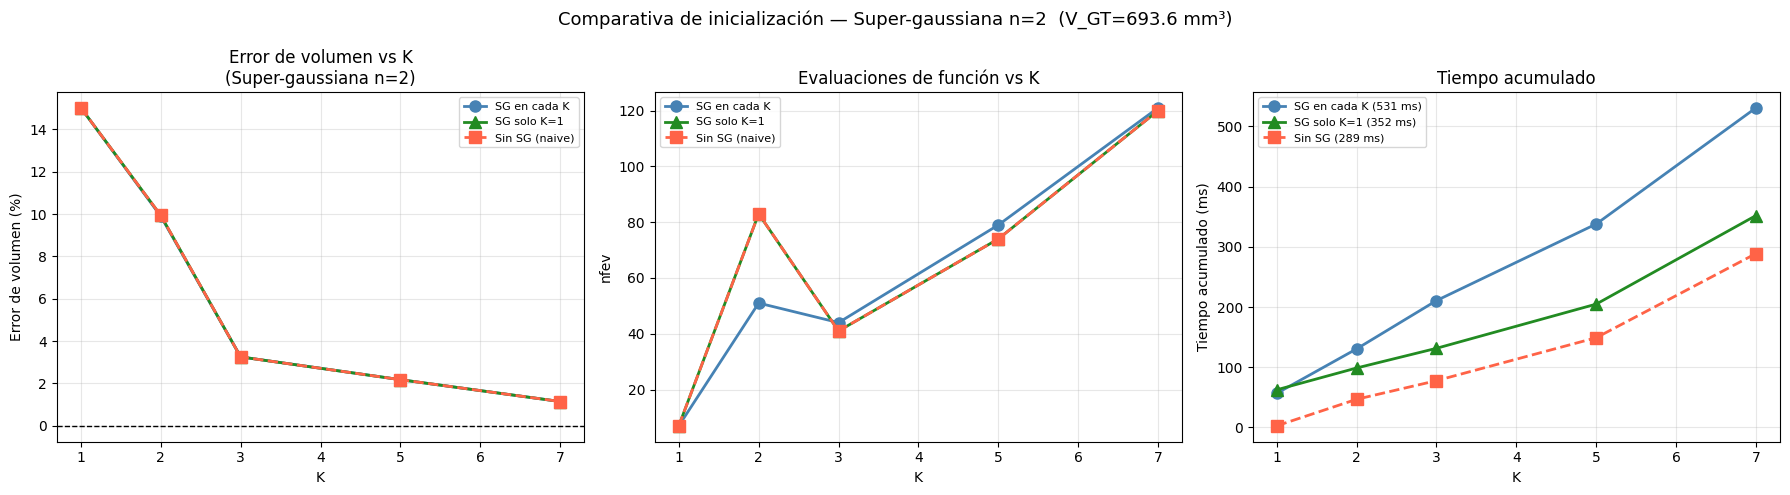

In [54]:
import time as _time

def _naive_ws(res_field, mask, x_vec_, y_vec_,
              fallback_sx=GT_SX*0.7, fallback_sy=GT_SY*0.7):
    """Inicialización simple: pico del residuo + σ fijos."""
    res_m = np.where(mask, res_field, -np.inf)
    pr_, pc_ = np.unravel_index(np.argmax(res_m), res_m.shape)
    return [float(res_m[pr_, pc_]), float(x_vec_[pc_]), float(y_vec_[pr_]),
            fallback_sx, fallback_sy, 0.0]

def _make_cached_fit(K_):
    """Devuelve (fun, jac) con caché para el K dado, usando x_sub/y_sub/z_sub del scope."""
    state = {'p': None, 'r': None, 'J': None}
    def _update(p):
        key = tuple(p)
        if key != state['p']:
            state['p'] = key
            state['r'], state['J'] = gauss_mixture_and_jac(p, x_sub, y_sub, K_)
    def fun(p): _update(p); return state['r'] - z_sub
    def jac(p): _update(p); return state['J']
    return fun, jac

def _run_multisplat(warm_start_fn):
    """
    Ejecuta el loop greedy sobre K_list con la función de warm start dada.
    warm_start_fn(res_field, mask, K) → lista de 6 params del nuevo splat
    Nota: usa len(p_cur)//6 como K_prev, para manejar K_list con saltos.
    """
    V_v, err_v, t_v, nfev_v = [], [], [], []
    p_cur = []
    for K in K_list:
        t0_ = _time.perf_counter()
        K_prev = len(p_cur) // 6   # K anterior real (puede diferir de K-1 si hay saltos)
        res_prev = np.zeros_like(Z_diff_n)
        if K_prev == 0:
            res_prev[rows_m, cols_m] = z_obs
            res_mask = mask_defect & mask_valid
        else:
            res_1d = z_obs - gauss_mixture(np.array(p_cur), x_obs, y_obs, K_prev).ravel()
            res_prev[rows_m, cols_m] = res_1d
            res_mask = (res_prev > SEG_THRESHOLD * GT_A * 0.5) & mask_valid
            if res_mask.sum() < 10:
                res_mask = mask_defect & mask_valid

        ws = warm_start_fn(res_prev, res_mask, K)
        # Añadir un splat a la vez aunque K salte (ej. de K=3 a K=5 se añade 1)
        p0 = list(p_cur) + ws
        p0 = [float(np.clip(v, lo+1e-6, hi-1e-6))
              for v, lo, hi in zip(p0, bounds_lo * (K_prev+1), bounds_hi * (K_prev+1))]

        K_fit = K_prev + 1
        fun, jac = _make_cached_fit(K_fit)
        res = _lsq(fun, p0, jac=jac,
                   bounds=(bounds_lo * K_fit, bounds_hi * K_fit),
                   method='trf', ftol=1e-6)
        p_cur = list(res.x)
        V = volume_mixture(p_cur, K_fit)
        t_v.append(_time.perf_counter() - t0_)
        V_v.append(V)
        err_v.append((V - V_gt) / V_gt * 100)
        nfev_v.append(res.nfev)

    return V_v, err_v, t_v, nfev_v

# ── Tres estrategias ──────────────────────────────────────────────────────────
WIN_RES_MM4 = 20.0
WIN_RES_PX4 = int(round(WIN_RES_MM4 / min(dx, dy))) | 1

def ws_sg_all(res_field, mask, K):
    return sg_warm_start_residuo(res_field, mask, WIN_RES_PX4, x_vec, y_vec, dx, dy,
                                 fallback_sx=GT_SX*0.7, fallback_sy=GT_SY*0.7)

def ws_sg_k1_only(res_field, mask, K):
    if K == K_list[0]:
        return sg_warm_start_residuo(res_field, mask, WIN_RES_PX4, x_vec, y_vec, dx, dy,
                                     fallback_sx=GT_SX*0.7, fallback_sy=GT_SY*0.7)
    return _naive_ws(res_field, mask, x_vec, y_vec)

def ws_naive(res_field, mask, K):
    return _naive_ws(res_field, mask, x_vec, y_vec)

print("── SG en cada K ──────────────────────────────────────────────")
V_sg_all, err_sg_all, t_sg_all, nfev_sg_all = _run_multisplat(ws_sg_all)
for K, e, nf, t in zip(K_list, err_sg_all, nfev_sg_all, t_sg_all):
    print(f"  K={K}: err={e:+.2f}%, nfev={nf:3d}, t={t*1e3:.1f} ms")

print("\n── SG solo en K=1, naive en K≥2 ────────────────────────────")
V_sg1, err_sg1, t_sg1, nfev_sg1 = _run_multisplat(ws_sg_k1_only)
for K, e, nf, t in zip(K_list, err_sg1, nfev_sg1, t_sg1):
    print(f"  K={K}: err={e:+.2f}%, nfev={nf:3d}, t={t*1e3:.1f} ms")

print("\n── Sin SG (naive) ────────────────────────────────────────────")
V_naive, err_naive, t_naive, nfev_naive = _run_multisplat(ws_naive)
for K, e, nf, t in zip(K_list, err_naive, nfev_naive, t_naive):
    print(f"  K={K}: err={e:+.2f}%, nfev={nf:3d}, t={t*1e3:.1f} ms")

# ── Tabla comparativa ─────────────────────────────────────────────────────────
print(f"\n{'K':>2}  {'SG en todos':>20}  {'SG solo K=1':>20}  {'Sin SG':>20}")
print("-" * 72)
for K, e1, nf1, t1, e2, nf2, t2, e3, nf3, t3 in zip(
        K_list,
        err_sg_all, nfev_sg_all, t_sg_all,
        err_sg1,    nfev_sg1,    t_sg1,
        err_naive,  nfev_naive,  t_naive):
    print(f"{K:>2}  {e1:>+7.2f}% {nf1:>3d}nfev {t1*1e3:>6.0f}ms"
          f"  {e2:>+7.2f}% {nf2:>3d}nfev {t2*1e3:>6.0f}ms"
          f"  {e3:>+7.2f}% {nf3:>3d}nfev {t3*1e3:>6.0f}ms")
print(f"{'Tot':>2}  {'':>9} {'':>6} {sum(t_sg_all)*1e3:>6.0f}ms"
      f"  {'':>9} {'':>6} {sum(t_sg1)*1e3:>6.0f}ms"
      f"  {'':>9} {'':>6} {sum(t_naive)*1e3:>6.0f}ms")

# ── Figura comparativa ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].axhline(0, color='k', ls='--', lw=1)
axes[0].plot(K_list, err_sg_all, 'o-',  color='steelblue',   lw=2, ms=8, label='SG en cada K')
axes[0].plot(K_list, err_sg1,    '^-',  color='forestgreen', lw=2, ms=8, label='SG solo K=1')
axes[0].plot(K_list, err_naive,  's--', color='tomato',      lw=2, ms=8, label='Sin SG (naive)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Error de volumen (%)')
axes[0].set_title(f'Error de volumen vs K\n(Super-gaussiana n={SG_N})'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(K_list, nfev_sg_all, 'o-',  color='steelblue',   lw=2, ms=8, label='SG en cada K')
axes[1].plot(K_list, nfev_sg1,    '^-',  color='forestgreen', lw=2, ms=8, label='SG solo K=1')
axes[1].plot(K_list, nfev_naive,  's--', color='tomato',      lw=2, ms=8, label='Sin SG (naive)')
axes[1].set_xlabel('K'); axes[1].set_ylabel('nfev')
axes[1].set_title('Evaluaciones de función vs K'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

t_cum1 = np.cumsum(t_sg_all) * 1e3
t_cum2 = np.cumsum(t_sg1)    * 1e3
t_cum3 = np.cumsum(t_naive)  * 1e3
axes[2].plot(K_list, t_cum1, 'o-',  color='steelblue',   lw=2, ms=8, label=f'SG en cada K ({t_cum1[-1]:.0f} ms)')
axes[2].plot(K_list, t_cum2, '^-',  color='forestgreen', lw=2, ms=8, label=f'SG solo K=1 ({t_cum2[-1]:.0f} ms)')
axes[2].plot(K_list, t_cum3, 's--', color='tomato',      lw=2, ms=8, label=f'Sin SG ({t_cum3[-1]:.0f} ms)')
axes[2].set_xlabel('K'); axes[2].set_ylabel('Tiempo acumulado (ms)')
axes[2].set_title('Tiempo acumulado'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle(f'Comparativa de inicialización — Super-gaussiana n={SG_N}  (V_GT={V_gt:.1f} mm³)', fontsize=13)
plt.tight_layout()
plt.show()

## Conclusiones

### 1. Model mismatch K=1 (splat único vs super-gaussiana)
Un único splat gaussiano sobreestima el volumen en **~+15%** cuando el defecto real es una super-gaussiana n=2. La forma más abrupta ("meseta plana con bordes abruptos") tiene menos cola que una gaussiana, pero el ajuste compensa subiendo el área σx·σy para encajar el centro, inflando el volumen estimado.

### 2. Multi-Splat greedy converge al volumen real
Con K=7 el error baja a **+0.53%**, demostrando que la mezcla de gaussianas puede aproximar formas no gaussianas arbitrariamente bien conforme aumenta K. La convergencia es rápida: ya en K=3 el error cae al ~3%.

### 3. El filtro SG como warm start no mejora la precisión final
Las tres estrategias probadas (SG en cada K / SG solo en K=1 / sin SG) convergen al **mismo error de volumen** para todos los K. El optimizador TRF llega al mismo mínimo desde cualquiera de los tres puntos de inicio porque el problema tiene poca multimodalidad local: el pico del residuo es ya un buen estimador de posición.

### 4. El SG warm start añade coste sin beneficio en precisión
Cada llamada al filtro SG cuesta ~55–65 ms (filtro sobre imagen 512×614). En "SG en todos" ese coste se paga en cada K, resultando en 531 ms totales frente a 289 ms sin SG. La estrategia óptima para este tipo de defecto es **inicialización naive (pico + σ fijos)**.

### 5. El SG sigue siendo valioso para estimación nominal
El filtro SG sí aporta donde no hay alternativa: estimar R sin CAD (error < 6 µm) a partir de la curvatura del anillo de sensing. Esa aplicación no tiene sustituto simple.

### 6. Optimizaciones de rendimiento
- **Jacobiano analítico**: elimina las 6·K llamadas extra de diferencias finitas por paso → ×8 speedup en el Jacobiano.
- **Subsampling N=1500** de N_obs=14191: la SVD interna de TRF pasa de 8.9 ms/paso a 1.6 ms/paso → ×5.7 speedup.
- **_CachedFit**: evita recalcular (r, J) cuando scipy llama `fun` y `jac` con el mismo punto.
- Combinados: K=1..7 completo en **~290 ms** frente a ~58 s con el enfoque original.